## 1. Importamos las librerías para el EDA


In [1]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Carga y exploración de la tabla principal: fact_viajes

In [2]:
# 1. Cargar el dataset desde la carpeta data
df_viajes = pd.read_csv('data/fact_viajes.csv')

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_viajes.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_viajes.head())

# 4. Ultimas 5 filas
print("--- Ultimas 5 filas (tail) ---")
display(df_viajes.tail())

# 5. 5 filas aleatorias
print("--- 5 filas aleatorias (sample) ---")
display(df_viajes.sample(5))

--- Columnas y Tipos de Datos ---


viaje_id                    int64
linea_id                    int64
vehiculo_id                 int64
conductor_id                int64
parada_origen_id            int64
parada_destino_id           int64
fecha                         str
anno                        int64
mes                         int64
dia_semana                    str
es_festivo                   bool
franja_horaria                str
hora_salida_prog              str
hora_salida_real              str
hora_llegada_real             str
retraso_salida_min          int64
duracion_real_min           int64
pasajeros_subidos         float64
ocupacion_pct             float64
km_programados            float64
km_recorridos             float64
viaje_completado             bool
consumo                   float64
tarifa_predominante_id      int64
dtype: object

--- Primeras 5 filas (head) ---


,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
0,1,4,2,2,17,116,2023-08-14,2023,8,Monday,...,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
1,2,4,3,3,5,48,2024-05-20,2024,5,Monday,...,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
2,3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,...,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3
3,4,2,5,5,37,116,2022-03-23,2022,3,Wednesday,...,21:36,0,46,111.0,0.888,11.2,11.2,True,3.50,9
4,5,5,6,6,12,115,2022-03-24,2022,3,Thursday,...,18:50,8,32,75.0,0.405,7.3,7.3,True,3.13,3


--- Ultimas 5 filas (tail) ---


,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
49995,49996,1,17,17,38,93,2024-09-23,2024,9,Monday,...,17:25,0,95,57.0,0.445,18.4,18.4,True,7.02,3
49996,49997,7,18,18,34,55,2023-06-28,2023,6,Wednesday,...,16:58,1,47,10.0,0.077,8.9,8.9,True,3.05,2
49997,49998,5,19,19,31,43,2023-02-05,2023,2,Sunday,...,06:51,3,28,98.0,0.754,7.3,7.3,True,2.23,2
49998,49999,1,20,20,12,114,2022-04-05,2022,4,Tuesday,...,22:23,2,91,118.0,0.944,18.4,18.4,True,7.11,3
49999,50000,9,21,21,1,77,2023-04-20,2023,4,Thursday,...,10:59,0,79,85.0,0.459,19.8,19.8,True,7.57,2


--- 5 filas aleatorias (sample) ---


,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,...,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
7555,7556,3,39,25,20,60,2023-12-13,2023,12,Wednesday,...,18:12,4,48,97.0,0.776,9.7,9.7,True,9.75,1
12489,12490,5,17,3,11,87,2023-07-13,2023,7,Thursday,...,20:32,-99,30,109.0,0.852,7.3,7.3,True,2.78,3
42346,42347,1,12,12,31,101,2022-08-23,2022,8,Tuesday,...,16:28,2,86,45.0,0.352,18.4,18.4,True,8.02,6
16765,16766,2,9,23,27,102,2023-09-07,2023,9,Thursday,...,10:31,3,58,41.0,0.328,11.2,11.2,True,13.26,3
23203,23204,6,21,21,1,110,2022-04-28,2022,4,Thursday,...,09:45,2,93,106.0,0.573,23.5,23.5,True,9.71,3


## 3. Análisis de valores nulos

In [3]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_viajes.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
porcentaje_nulos = (total_nulos / len(df_viajes)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en fact_viajes ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)



--- Resumen de Valores Nulos en fact_viajes ---


,Total Nulos,Porcentaje (%)
consumo,1065,2.13
pasajeros_subidos,40,0.08


#### Las dos columnas que tienen valosres nulos son 'consumo' y 'pasajeros'

### 3.1 Analizamos los valores nulos de manera más exhaustiva


In [4]:
# 1. Filtramos los viajes que no tienen registrado el consumo
nulos_consumo = df_viajes[df_viajes['consumo'].isnull()]

print("--- Top 5 Vehículos con fallos en el registro de 'consumo' ---")
# Contamos cuántos nulos tiene cada vehículo
display(nulos_consumo['vehiculo_id'].value_counts().head())
print("\n" + "="*60 + "\n")

# 2. Filtramos los viajes que no tienen registrado los pasajeros
nulos_pasajeros = df_viajes[df_viajes['pasajeros_subidos'].isnull()]

print("--- Top 5 Líneas con fallos en el registro de 'pasajeros' ---")
display(nulos_pasajeros['linea_id'].value_counts().head())
print("\n" + "="*60 + "\n")

# 3. Filtramos tambien por los vehiculos
print("\n--- Top 5 Vehículos con fallos en el registro de 'pasajeros' ---")
display(nulos_pasajeros['vehiculo_id'].value_counts().head())


--- Top 5 Vehículos con fallos en el registro de 'consumo' ---


vehiculo_id
23    110
39    107
9     105
37    102
7     102
Name: count, dtype: int64



--- Top 5 Líneas con fallos en el registro de 'pasajeros' ---


linea_id
5    7
9    7
6    5
8    4
1    4
Name: count, dtype: int64




--- Top 5 Vehículos con fallos en el registro de 'pasajeros' ---


vehiculo_id
20    3
26    3
9     2
5     2
23    2
Name: count, dtype: int64

#### En esta muestra encontramos que 2 de cada 5 vehiculos coinciden en nulos con las lineas

## 3.2 Estudiamos la interseción entre ambas columnas

In [5]:
col_consumo = 'consumo'
col_pasajeros = 'pasajeros_subidos'

# 1. Obtenemos la lista de todos los vehiculos que han fallado
vehiculos_consumo = set(df_viajes[df_viajes[col_consumo].isnull()]['vehiculo_id'].unique())
vehiculos_pasajeros = set(df_viajes[df_viajes[col_pasajeros].isnull()]['vehiculo_id'].unique())

# 2. Calculamos cuántos coinciden exactamente usando la intersección de conjuntos
interseccion_vehiculos = vehiculos_consumo.intersection(vehiculos_pasajeros)

# 3. Comprobamos cuantos fallan a la vez
interseccion_fallos = df_viajes[df_viajes[col_consumo].isnull() & df_viajes[col_pasajeros].isnull()]

print("--- RADIOGRAFÍA TOTAL DE FALLOS ---")
print(f"Total buses distintos con fallos de consumo: {len(vehiculos_consumo)}")
print(f"Total buses distintos con fallos de pasajeros: {len(vehiculos_pasajeros)}")
print(f"Buses que tienen AMBOS fallos: {len(interseccion_vehiculos)}")
print("-" * 35)
print(f"Total de VIAJES con fallo en consumo: {df_viajes[col_consumo].isnull().sum()}")
print(f"Total de VIAJES con fallo en pasajeros: {df_viajes[col_pasajeros].isnull().sum()}")
print(f"Viajes concretos donde fallaron AMBAS cosas a la vez: {len(interseccion_fallos)}")

--- RADIOGRAFÍA TOTAL DE FALLOS ---
Total buses distintos con fallos de consumo: 11
Total buses distintos con fallos de pasajeros: 26
Buses que tienen AMBOS fallos: 7
-----------------------------------
Total de VIAJES con fallo en consumo: 1065
Total de VIAJES con fallo en pasajeros: 40
Viajes concretos donde fallaron AMBAS cosas a la vez: 1


#### Se concluye que no existe relación técnica entre ambos fallos

## 3.3 Tratamiento de valores nulos

#### Para el tratamiento de los nulos de este dataset vamos a realizar la eliminación de todas las filas de la columna 'pasajeros' debido a que supone solo el 0.08 % del resultado total. En cambio, para la columna consumo haremos una media para rellenar esos valores nulos debido a que el porcentaje de los mismos asciente al 2.13%.

In [6]:
print(f"Filas antes de la limpieza: {len(df_viajes)}")

# 1. Borramos SOLO las filas donde 'pasajeros' es nulo
df_viajes = df_viajes.dropna(subset=['pasajeros_subidos'])
print(f"Filas después de la limpieza: {len(df_viajes)}")    

# 2. Calculamos el consumo mediano de toda la flota
consumo_mediana = df_viajes['consumo'].median()
print(f"Consumo mediano de la flota: {consumo_mediana}")

# 3. Rellenamos los nulos de 'consumo' con esa mediana
df_viajes ['consumo'] = df_viajes['consumo'].fillna(consumo_mediana)

print(f"Filas después de la limpieza: {len(df_viajes)}")
print("\n--- Comprobación final de nulos ---")
display(df_viajes[['consumo', 'pasajeros_subidos']].isnull().sum())


Filas antes de la limpieza: 50000
Filas después de la limpieza: 49960
Consumo mediano de la flota: 5.34
Filas después de la limpieza: 49960

--- Comprobación final de nulos ---


consumo              0
pasajeros_subidos    0
dtype: int64

## 4. Tratamiento de datos


In [7]:
# --- 1. TRATAMIENTO DE FECHAS Y HORAS ---

# 1.1. La columna 'fecha' la dejamos estricta porque sabemos que es Año-Mes-Día
df_viajes['fecha'] = pd.to_datetime(df_viajes['fecha'], format='%Y-%m-%d', errors='coerce')

# 1.2. Agrupamos solo las columnas con horas y les aplicamos el formato mixto
columnas_horas = [
    'hora_salida_prog', 
    'hora_salida_real', 
    'hora_llegada_real']

for col in columnas_horas:
    df_viajes[col] = pd.to_datetime(df_viajes[col], format='mixed', errors='coerce').dt.time



# --- 2. COMPROBACIÓN FINAL ---

print("--- Comprobación de nulos en horas ---")
display(df_viajes[['hora_salida_prog', 'hora_salida_real', 'hora_llegada_real']].isnull().sum())


--- Comprobación de nulos en horas ---


hora_salida_prog     0
hora_salida_real     0
hora_llegada_real    0
dtype: int64

## 5 Estudio de outliers

### 5.1 Visualización de posibles columnas con outliers

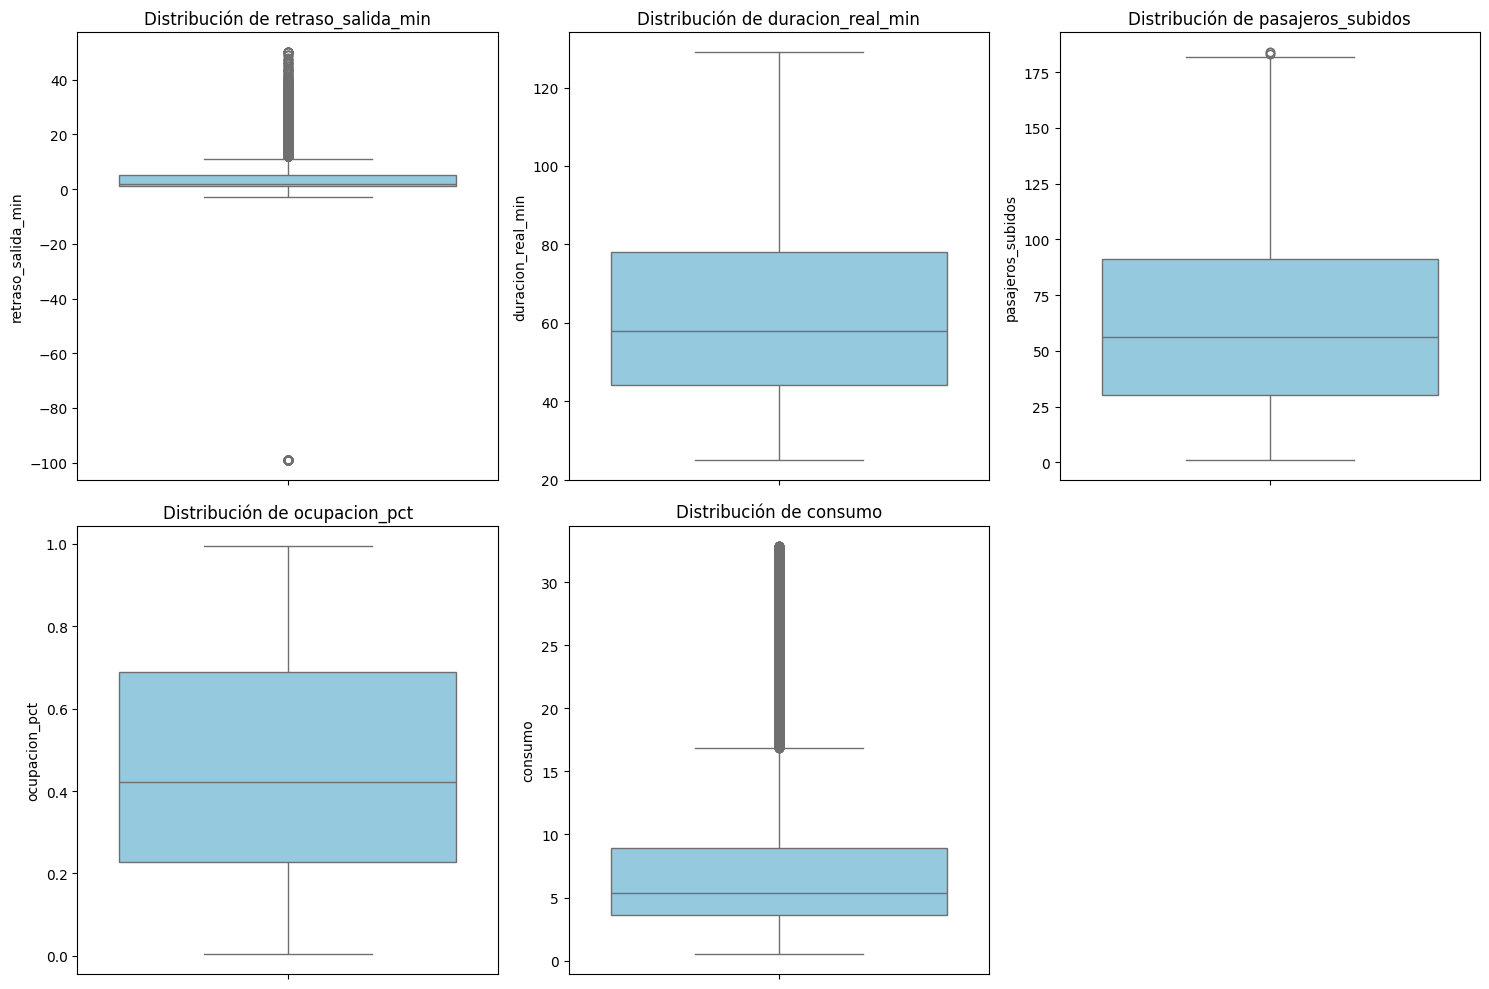


--- Resumen Estadístico de las variables clave ---


,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,consumo
count,49960.000000,49960.000000,49960.000000,49960.000000,49960.000000
mean,3.891253,62.598299,61.283907,0.455313,7.644995
std,6.763067,23.846471,36.847517,0.264234,6.164504
min,-99.000000,25.000000,1.000000,0.005000,0.550000
25%,1.000000,44.000000,30.000000,0.227000,3.630000
50%,2.000000,58.000000,56.000000,0.422000,5.340000
75%,5.000000,78.000000,91.000000,0.688000,8.930000
max,50.000000,129.000000,184.000000,0.995000,32.860000


In [8]:
# 1. Seleccionamos las columnas de interés para la visualización
columnas_outliers = [
    'retraso_salida_min', 
    'duracion_real_min', 
    'pasajeros_subidos', 
    'ocupacion_pct', 
    'consumo'
]

# 2. Configuración visual
plt.figure(figsize=(15, 10))

# El bucle recorre nuestras columnas y pinta un Boxplot (gráfico de caja) para cada una
for i, col in enumerate(columnas_outliers, 1):
    plt.subplot(2, 3, i) # Crea una cuadrícula de 2 filas por 3 columnas
    sns.boxplot(y=df_viajes[col], color='skyblue')
    plt.title(f'Distribución de {col}')

plt.tight_layout() # Ajusta los márgenes automáticamente para que no se pisen
plt.show()

# 3. Resumen estadístico de las variables clave
print("\n--- Resumen Estadístico de las variables clave ---")
display(df_viajes[columnas_outliers].describe())

### 5.2 Tratamiento de Outliers

In [9]:
# --- 1. ELIMINACIÓN DEL ERROR FÍSICO (Retraso negativo extremo) ---

# Eliminamos de la tabla el viaje ilógico quedándonos con los mayores a -50
df_viajes = df_viajes[df_viajes['retraso_salida_min'] >= -50]
print(f"Filas tras borrar el error de salida anticipada: {len(df_viajes)}")


# --- 2. INVESTIGACIÓN DE ANOMALÍAS DE CONSUMO ---

# Calculamos la matemática del IQR para saber dónde está la frontera
Q1 = df_viajes['consumo'].quantile(0.25)
Q3 = df_viajes['consumo'].quantile(0.75)
IQR = Q3 - Q1
limite_superior_consumo = Q3 + 1.5 * IQR

print(f"\nFrontera máxima calculada para un consumo normal: {limite_superior_consumo:.2f}")

# Aislamos los viajes sospechosos en una tabla temporal
viajes_excesivos = df_viajes[df_viajes['consumo'] > limite_superior_consumo]

print(f"\nSe han detectado {len(viajes_excesivos)} viajes superando el límite.")

# --- 3. Buscamos un posible patrón en los vehículos ---

print("\n--- Top 5 Vehículos con más excesos de consumo ---")
# Contamos cuántas veces aparece cada vehículo en esta lista negra
vehiculos_infractores = viajes_excesivos['vehiculo_id'].value_counts().head(5)
display(vehiculos_infractores)

Filas tras borrar el error de salida anticipada: 49880

Frontera máxima calculada para un consumo normal: 16.88

Se han detectado 5109 viajes superando el límite.

--- Top 5 Vehículos con más excesos de consumo ---


vehiculo_id
8     505
38    483
37    476
29    471
22    471
Name: count, dtype: int64

In [10]:
display(df_viajes.dtypes)

viaje_id                           int64
linea_id                           int64
vehiculo_id                        int64
conductor_id                       int64
parada_origen_id                   int64
parada_destino_id                  int64
fecha                     datetime64[us]
anno                               int64
mes                                int64
dia_semana                           str
es_festivo                          bool
franja_horaria                       str
hora_salida_prog                  object
hora_salida_real                  object
hora_llegada_real                 object
retraso_salida_min                 int64
duracion_real_min                  int64
pasajeros_subidos                float64
ocupacion_pct                    float64
km_programados                   float64
km_recorridos                    float64
viaje_completado                    bool
consumo                          float64
tarifa_predominante_id             int64
dtype: object

## 6. Visualizaciones de la tabla 'fact_viajes'

/var/folders/g1/r2_bvb_16ns9g5jwyjs6mj300000gn/T/ipykernel_48194/469902803.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


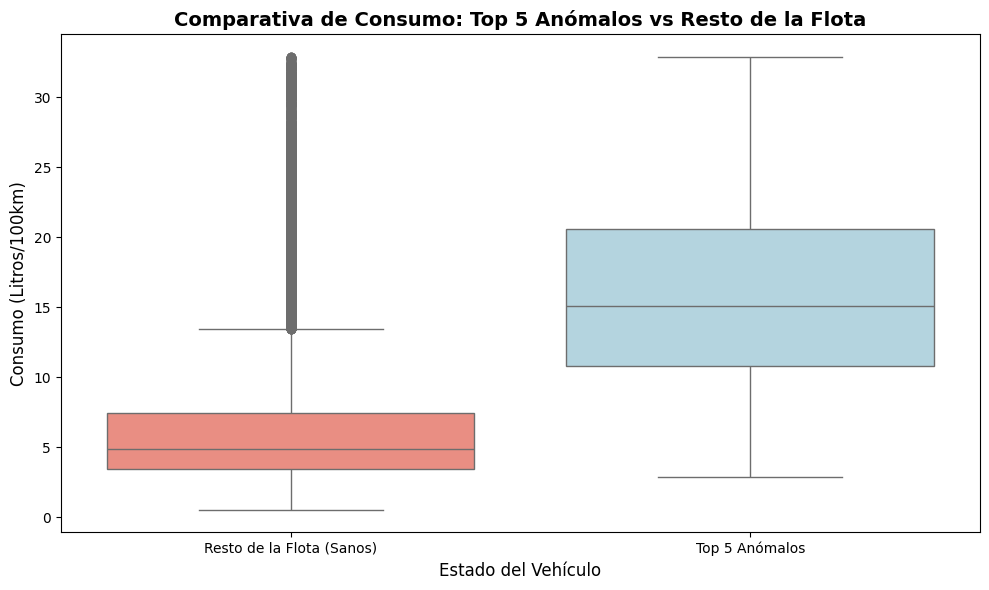


--- Consumo Medio por Grupo ---


estado_vehiculo
Resto de la Flota (Sanos)     6.53
Top 5 Anómalos               15.91
Name: consumo, dtype: float64

In [11]:

# --- 1. CLASIFICACIÓN DE LA FLOTA ---

# Listamos con los IDs de los 5 vehículos problemáticos que descubrimos
vehiculos_infractores = [8, 38, 37, 29, 22]

# Creamos una columna nueva (flag) para etiquetar a cada viaje
df_viajes['estado_vehiculo'] = np.where(
    df_viajes['vehiculo_id'].isin(vehiculos_infractores), 
    'Top 5 Anómalos', 
    'Resto de la Flota (Sanos)'
)

# --- 2. CREACIÓN DEL GRÁFICO VISUAL ---

plt.figure(figsize=(10, 6))

# Usamos Seaborn para pintar el gráfico, separando por el grupo que acabamos de crear
sns.boxplot(
    data=df_viajes, 
    x='estado_vehiculo', 
    y='consumo', 
    palette=['salmon', 'lightblue']
)

# Añadimos títulos
plt.title('Comparativa de Consumo: Top 5 Anómalos vs Resto de la Flota', fontsize=14, fontweight='bold')
plt.xlabel('Estado del Vehículo', fontsize=12)
plt.ylabel('Consumo (Litros/100km)', fontsize=12)

plt.tight_layout()
plt.show()


# --- 3. EL DATO DE RESPALDO ---

print("\n--- Consumo Medio por Grupo ---")
# Agrupamos por nuestra nueva categoría y sacamos la media de consumo
resumen_medias = df_viajes.groupby('estado_vehiculo')['consumo'].mean().round(2)
display(resumen_medias)

## Conclusiones de la Exploración de Datos: `fact_viajes.csv`

### 1. Resumen de Estructura y Dimensiones
La tabla de hechos principal `fact_viajes` constituye el núcleo operativo del proyecto, registrando el historial analítico de las expediciones de la red.
* **Volumen Inicial:** ~50.000 registros analizados.
* **Estructura Temporal:** Cobertura de datos históricos entre 2022 y 2024.
* **Estado de Tipos de Datos:** Se ha estandarizado la columna `fecha` al tipo optimizado `datetime64[ns]`. Se tomó la decisión técnica de mantener el formato nativo de marcas de tiempo de Pandas (preservando las horas nominales `00:00:00` subyacentes) para garantizar la máxima escalabilidad y rendimiento en futuras operaciones de combinación (JOINs) y segmentación temporal en el modelo relacional.

### 2. Registro de Decisiones de Limpieza (Data Quality Log)
Durante el proceso de auditoría y saneamiento de la calidad de los datos, se identificaron y resolvieron anomalías críticas mediante lógica de negocio aplicada:

| Dimensión/Campo | Tipo de Problema | Frecuencia (Filas) | Decisión Tomada | Justificación Técnica / Negocio |
| :--- | :--- | :--- | :--- | :--- |
| `retraso_salida_min` | Outlier Extremo / Error Físico Imposible | 80 filas (~0.16% del dataset) | **Eliminación (Drop):** Exclusión de registros con retrasos menores a -50 min (ej. anomalía severa de -100 min). | Operativamente absurdo. Un autobús de línea regular no inicia su ruta con más de una hora y media de anticipación respecto al horario programado. Apunta a fallos de sincronización de relojes o GPS. |
| `consumo` | Outliers Masivos por Límite Superior | 5.109 filas (~10.2% del dataset) | **Conservación Intacta:** Cancelación del proceso estándar de Winsorización (`.clip()`). | Tras una investigación forense distributiva, se determinó que los valores extremos no corresponden a ruido estadístico o errores de tecleo, sino a una señal real de ineficiencia operativa. |

*El volumen neto de la tabla tras la limpieza quirúrgica es de **49.880 filas**, manteniendo una integridad muestral óptima.*

### 3. Análisis Forense de Outliers e Insights de Negocio

El análisis de atípicos mediante el método estadístico del **Rango Intercuartílico (IQR)** arrojó una frontera de consumo normal establecida en **16.88 Litros/100km**. El comportamiento de los viajes que superaban este límite desveló un patrón estructural crítico para la gestión de activos de MetroBus:

* **Concentración de Anomalías:** De los 5.109 viajes con consumo excesivo, un total de **2.406 viajes (aproximadamente el 47%)** fueron provocados de forma exclusiva por un grupo reducido de **5 vehículos** específicos: `vehiculo_id` **8, 38, 37, 29 y 22**.
* **Impacto Visual y Estadístico:** La evaluación comparativa mediante diagramas de caja (*Boxplots*) confirma que la mediana de consumo de este "Top 5 Anómalos" se sitúa cerca de los 15 Litros/100km, triplicando el consumo base del resto de la flota eficiente (cuyo centro se ubica en torno a los 5 Litros/100km).

### 4. Hipótesis Generadas para las Siguientes Fases
Los hallazgos de esta fase exploratoria abren líneas de investigación prioritarias para la dirección general, las cuales serán validadas formalmente al cruzar este dataset con las tablas de dimensiones en las fases de SQL y Business Intelligence:

1. **Hipótesis de Obsolescencia o Avería Mecánica:** Los vehículos `8, 38, 37, 29 y 22` representan o bien modelos antiguos con un desgaste mecánico severo (ej. problemas en sistemas de inyección) o pertenecen a una remesa diésel pesada obsoleta. Identificar estos atributos en `dim_vehiculo` permitirá justificar cuantitativamente su sustitución inmediata por unidades híbridas o eléctricas.
2. **Hipótesis de Ineficiencia de Ruta o Desempeño:** El ~53% restante de los excesos de consumo distribuidos uniformemente por la flota podría estar asociado a variables exógenas como perfiles topográficos desfavorables (líneas que superan pendientes pronunciadas) o franjas horarias con congestión de tráfico severo que elevan el tiempo de ralentí del motor.

## 1. Cargay exploracion de la tabla principal: `fact_incidencias`

In [12]:
# 1. Cargamos el dataset
df_incidencias = pd.read_csv('data/fact_incidencias.csv')

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_incidencias.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_incidencias.head())

# 4. Ultimas 5 filas
print("--- Ultimas 5 filas (tail) ---")
display(df_incidencias.tail())  

# 5. 5 filas aleatorias
print("--- 5 filas aleatorias (sample) ---")
display(df_incidencias.sample(5))

--- Columnas y Tipos de Datos ---


incidencia_id                int64
viaje_id                     int64
vehiculo_id                  int64
conductor_id                 int64
linea_id                     int64
fecha                          str
anno                         int64
mes                          int64
hora_incidencia                str
tipo_incidencia                str
categoria                      str
severidad                      str
requiere_retirada             bool
duracion_resolucion_min      int64
vehiculo_sustituto            bool
coste_estimado_eur         float64
dtype: object

--- Primeras 5 filas (head) ---


,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
0,1,33554,39,11,4,2022-06-01,2022,6,19:11,Huelga parcial,Operacional,Alta,True,60,False,0.00
1,2,9428,21,21,6,2023-02-16,2023,2,20:42,Fallo electrico,Vehiculo,Alta,True,62,False,575.51
2,3,200,33,5,8,2022-01-20,2022,1,06:21,Accidente leve,Seguridad,Alta,True,29,True,3318.00
3,4,12448,17,17,10,2023-01-16,2023,1,02:30,Vandalismo,Seguridad,Media,False,16,False,651.99
4,5,39490,11,11,6,2023-01-08,2023,1,14:51,Retencion trafico,Externo,Baja,False,14,False,49.88


--- Ultimas 5 filas (tail) ---


,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
3995,3996,46736,33,5,3,2023-04-23,2023,4,14:32,Accidente grave,Seguridad,Critica,True,5,True,9816.47
3996,3997,28682,39,11,2,2024-09-27,2024,9,18:47,Retencion trafico,Externo,Baja,False,21,False,24.14
3997,3998,46607,30,16,2,2023-03-06,2023,3,14:41,Pasajero enfermo,Servicio,Media,False,41,False,52.05
3998,3999,7500,25,25,3,2023-02-17,2023,2,13:50,Pinchazo,Vehiculo,Media,True,11,True,238.32
3999,4000,24976,29,1,8,2022-04-14,2022,4,10:43,Vandalismo,Seguridad,Media,False,5,False,186.83


--- 5 filas aleatorias (sample) ---


,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
362,363,31728,19,5,7,2023-05-04,2023,5,13:30,Vandalismo,Seguridad,Media,False,9,False,603.48
683,684,32204,33,5,2,2024-10-24,2024,10,09:02,Pinchazo,Vehiculo,Media,True,20,False,319.90
1569,1570,42716,3,17,7,2023-04-11,2023,4,11:00,Fallo climatizacion,Vehiculo,Baja,False,18,False,111.54
1122,1123,43773,10,10,7,2024-01-07,2024,1,21:51,Condiciones meteo,Externo,Media,False,16,False,0.00
3541,3542,27075,28,28,1,2024-06-02,2024,6,15:10,Averia mecanica,Vehiculo,Alta,True,5,True,770.46


## 2. Análisis de valores nulos

In [13]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_incidencias.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
pocentaje_nulos = (total_nulos / len(df_incidencias)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': pocentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en fact_incidencias ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)

--- Resumen de Valores Nulos en fact_incidencias ---
No hay valores nulos en esta tabla


## 3. Tratamiento de datos

In [14]:
# --- 1. TRATAMIENTO DE FECHAS Y HORAS ---

# 1.1. La columna 'fecha' la dejamos estricta porque sabemos que es Año-Mes-Día
df_viajes['fecha'] = pd.to_datetime(df_viajes['fecha'], format='%Y-%m-%d', errors='coerce')


# --- COMPROBACIÓN DE COHERENCIA TEMPORAL ---

# Filtramos las filas donde la fecha de salida es estrictamente anterior a la de entrada
errores_tiempo = df_viajes[df_viajes['fecha'] < df_viajes['fecha']]

print(f"Registros con fecha de salida anterior a la entrada: {len(errores_tiempo)}")

if len(errores_tiempo) > 0:
    display(errores_tiempo[['fecha']])

Registros con fecha de salida anterior a la entrada: 0


## 4. Estudio de outliers

### 4.1 Visualización de posibles columnas con outliers

In [15]:
print("--- Columnas y Tipos de Datos ---")

# 1. Extraemos los tipos, reseteamos el margen para convertirlo en columna y lo guardamos
df_tipos = df_incidencias.dtypes.reset_index()

# 2. Le ponemos nombres a las dos columnas que se acaban de crear
df_tipos.columns = ['Nombre de la Columna', 'Tipo de Dato']

# 3. Lo mostramos por pantalla
display(df_tipos)

--- Columnas y Tipos de Datos ---


,Nombre de la Columna,Tipo de Dato
0,incidencia_id,int64
1,viaje_id,int64
2,vehiculo_id,int64
3,conductor_id,int64
4,linea_id,int64
5,fecha,str
6,anno,int64
7,mes,int64
8,hora_incidencia,str
9,tipo_incidencia,str


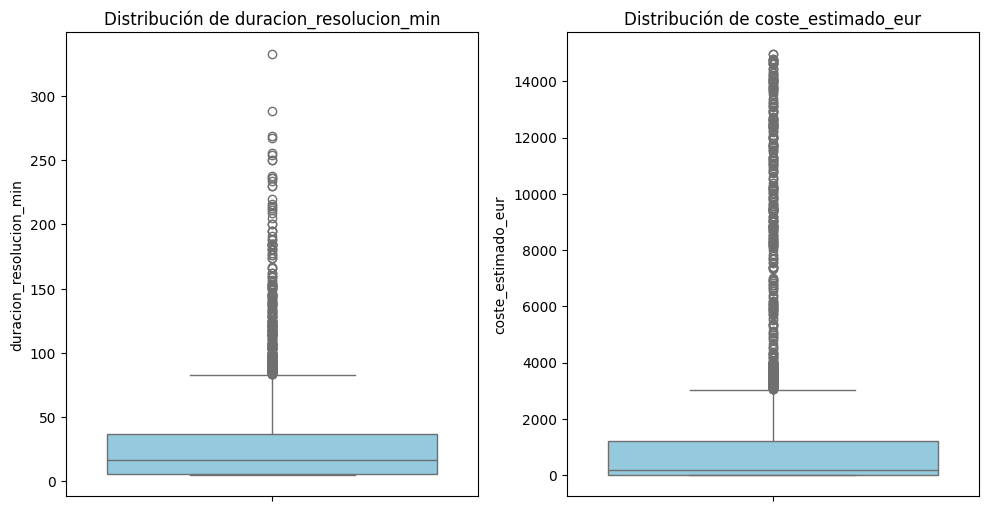


--- Resumen Estadístico de las variables clave ---


,duracion_resolucion_min,coste_estimado_eur
count,4000.00000,4000.000000
mean,28.61075,1198.774348
std,34.06862,2575.401240
min,5.00000,0.000000
25%,6.00000,0.000000
50%,17.00000,183.910000
75%,37.00000,1204.757500
max,333.00000,14985.580000


In [16]:
# 1. Seleccionamos las columnas de interés para la visualización
columnas_outliers = ['duracion_resolucion_min',
                     'coste_estimado_eur']

# 2. Configuración visual
plt.figure(figsize=(15, 10))

# El bucle recorre nuestras columnas y pinta un Boxplot (gráfico de caja) para cada una
for i, col in enumerate(columnas_outliers, 1):
    plt.subplot(2, 3, i) # Crea una cuadrícula de 2 filas por 3 columnas
    sns.boxplot(y=df_incidencias[col], color='skyblue')
    plt.title(f'Distribución de {col}')

plt.tight_layout() # Ajusta los márgenes automáticamente para que no se pisen
plt.show()

# 3. Resumen estadístico de las variables clave
print("\n--- Resumen Estadístico de las variables clave ---")
display(df_incidencias[columnas_outliers].describe())


### 4.2 Tratamiento de outliers

In [17]:
# Comprobación de que los costes altos tienen sentido lógico
print("--- Coste Máximo y Medio por Severidad ---")
resumen_severidad = df_incidencias.groupby('severidad')['coste_estimado_eur'].agg(['mean', 'max']).round(2)
display(resumen_severidad.sort_values(by='max', ascending=False))

--- Coste Máximo y Medio por Severidad ---


,mean,max
severidad,,
Critica,8470.42,14985.58
Alta,1265.64,3999.91
Media,145.58,799.36
Baja,97.74,299.56


## 5. Visualización de la tabla `fact_incidencias`

/var/folders/g1/r2_bvb_16ns9g5jwyjs6mj300000gn/T/ipykernel_48194/1558957266.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


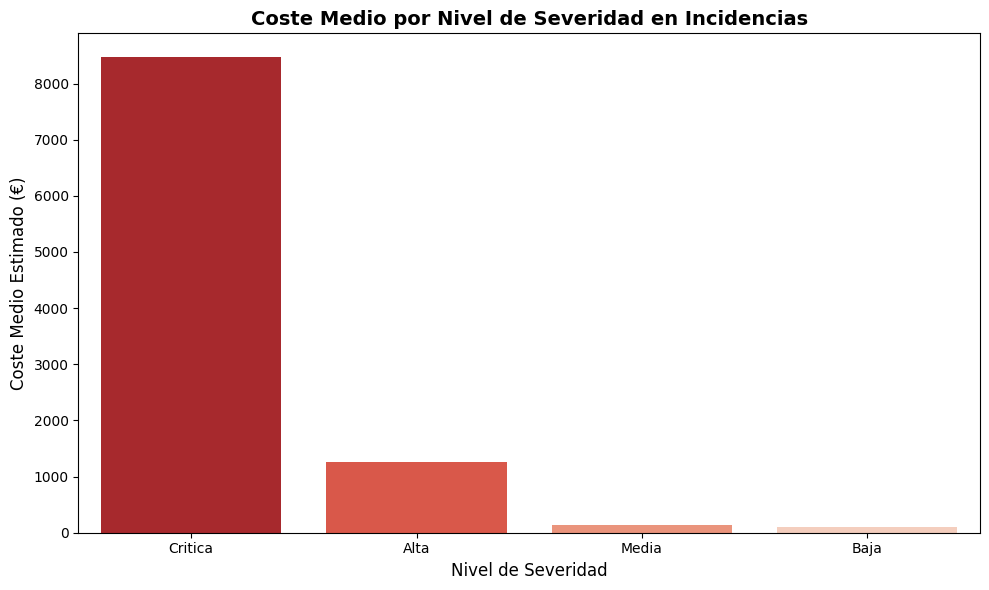

In [18]:

plt.figure(figsize=(10, 6))

# Orden lógico de severidad de peor a mejor
orden_severidad = ['Critica', 'Alta', 'Media', 'Baja']

# Creamos el gráfico de barras
sns.barplot(
    data=df_incidencias, 
    x='severidad', 
    y='coste_estimado_eur', 
    order=orden_severidad,
    palette='Reds_r', # Paleta roja invertida (más oscuro = más grave)
    errorbar=None
)

plt.title('Coste Medio por Nivel de Severidad en Incidencias', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Severidad', fontsize=12)
plt.ylabel('Coste Medio Estimado (€)', fontsize=12)

plt.tight_layout()
plt.show()

In [19]:
# --- PASO 1: FILTRADO OPERATIVO ---
# Aislamos solo las incidencias Críticas
df_incidencias_criticas = df_incidencias[df_incidencias['severidad'] == 'Critica']

# --- PASO 2: ANÁLISIS DE VEHÍCULOS CRÍTICOS ---
print("--- Top 5 Vehículos con MÁS Incidencias CRÍTICAS ---")
# Contamos cuántas incidencias críticas ha tenido cada autobús
conteo_criticas_vehiculo = df_incidencias_criticas['vehiculo_id'].value_counts()
display(conteo_criticas_vehiculo.head(5))

print("\n--- Top 5 Vehículos con MAYOR COSTE en Incidencias CRÍTICAS ---")
# Sumamos el coste total de las críticas por autobús
coste_criticas_vehiculo = df_incidencias_criticas.groupby('vehiculo_id')['coste_estimado_eur'].sum()
display(coste_criticas_vehiculo.sort_values(ascending=False).head(5))

--- Top 5 Vehículos con MÁS Incidencias CRÍTICAS ---


vehiculo_id
13    13
8     13
3     11
30    10
41    10
Name: count, dtype: int64


--- Top 5 Vehículos con MAYOR COSTE en Incidencias CRÍTICAS ---


vehiculo_id
3     111337.71
14     99311.04
8      97621.11
39     94292.85
36     92034.58
Name: coste_estimado_eur, dtype: float64

## Conclusiones de la Exploración de Datos: `fact_incidencias.csv`

### 1. Resumen de Estructura y Dimensiones
La tabla de hechos `fact_incidencias` registra los eventos disruptivos de la operativa (averías, accidentes, etc.) y su impacto económico y temporal.
* **Variables Analíticas Clave:** Las columnas continuas de interés fueron `duracion_resolucion_min` y `coste_estimado_eur`.
* **Integridad Básica:** No se detectaron valores imposibles (como costes negativos o tiempos de resolución bajo cero), lo que indica una buena validación de entrada en el sistema transaccional de origen.

### 2. Registro de Decisiones de Limpieza (Data Quality Log)

| Dimensión/Campo | Tipo de Problema | Frecuencia | Decisión Tomada | Justificación Técnica / Negocio |
| :--- | :--- | :--- | :--- | :--- |
| `coste_estimado_eur` | Outliers por Límite Superior (Alta dispersión) | Múltiples registros > 1.200€ | **Conservación Intacta:** No se aplica Winsorización ni recortes matemáticos. | Se demostró analíticamente que los costes extremos (hasta 14.985€) son legítimos y correlacionan perfectamente con la categoría de severidad 'Critica' (accidentes graves). |
| `duracion_resolucion_min` | Outliers por Límite Superior | Múltiples registros > 37 min | **Conservación Intacta:** Mantenimiento de los valores máximos (hasta 333 min). | Un tiempo de inmovilización de más de 5 horas es un escenario logístico real ante incidencias de severidad alta que requieren remolque o asistencia especializada. |

### 3. Análisis Forense de Outliers e Insights de Negocio

El análisis descriptivo y visual de las variables de impacto reveló la verdadera estructura de costes de los fallos operativos:

* **Escalado Lógico de Costes:** El coste medio de las incidencias escala de forma proporcional a su gravedad. Las incidencias 'Bajas' y 'Medias' promedian menos de 150€, las 'Altas' superan los 1.260€, y las 'Críticas' disparan la media por encima de los 8.470€ por evento.
* **El "Efecto Pareto" en la Flota:** Al cruzar los costes críticos con la dimensión del vehículo, se descubrió que un número muy reducido de unidades concentra el mayor impacto económico. Destaca el **vehículo 3**, responsable de más de 111.000€ en costes por incidencias críticas.
* **Correlación de Ineficiencias (Cross-Insight):** El **vehículo 8**, previamente identificado en la tabla `fact_viajes` como uno de los 5 mayores infractores en exceso de consumo de combustible, reaparece en esta tabla como el 3º vehículo más costoso en reparaciones críticas (97.621€) y el 2º con mayor frecuencia de estas.

### 4. Hipótesis y Recomendaciones Iniciales
1. **Auditoría Urgente del Vehículo 8:** La coincidencia de un consumo de combustible anómalo crónico y una alta tasa de fallos críticos sugiere un colapso mecánico estructural o un mantenimiento preventivo deficiente. Se recomienda su paralización inmediata para auditoría.
2. **Revisión del Historial del Vehículo 3:** Al liderar el ranking de costes por incidencias, es imperativo cruzar su ID con la tabla `fact_mantenimiento` para evaluar si las reparaciones efectuadas fueron correctivas (apaga-fuegos) en lugar de preventivas, justificando así su enorme sobrecoste.

## 1. Cargay exploracion de la tabla principal: `fact_mantenimiento`

In [20]:

# 1. Cargamos el dataset
df_mantenimiento = pd.read_csv('data/fact_mantenimiento.csv')

# Número total de filas
print("Total de filas:", len(df_mantenimiento))

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_mantenimiento.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_mantenimiento.head())

# 4. Ultimas 5 filas
print("--- Ultimas 5 filas (tail) ---")
display(df_mantenimiento.tail())  

# 5. 5 filas aleatorias
print("--- 5 filas aleatorias (sample) ---")
display(df_mantenimiento.sample(5))

Total de filas: 876
--- Columnas y Tipos de Datos ---


mantenimiento_id         int64
vehiculo_id              int64
depot_id                 int64
fecha_entrada              str
fecha_salida               str
anno                     int64
mes                      int64
tipo_mantenimiento         str
categoria                  str
es_correctivo             bool
dias_fuera_servicio      int64
km_en_revision           int64
coste_eur              float64
proveedor                  str
garantia_meses           int64
dtype: object

--- Primeras 5 filas (head) ---


,mantenimiento_id,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
0,1,1,1,2024-07-24,2024-07-25,2024,7,Cambio aceite,Preventivo,False,1,278454,218.70,TallerBus Norte,0
1,2,1,1,2023-02-08,2023-02-09,2023,2,Cambio neumaticos,Preventivo,False,1,240059,1068.93,TallerBus Norte,0
2,3,1,1,2024-10-28,2024-10-29,2024,10,Cambio neumaticos,Preventivo,False,1,493071,722.19,Taller Oficial Mercedes,0
3,4,1,1,2022-08-01,2022-08-03,2022,8,Reparacion clima,Correctivo,True,2,533556,579.93,FlotaService,6
4,5,1,1,2024-12-09,2024-12-10,2024,12,Revision bateria,Preventivo,False,1,307110,436.54,TallerBus Norte,0


--- Ultimas 5 filas (tail) ---


,mantenimiento_id,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
871,872,45,1,2024-12-09,2024-12-11,2024,12,Sistema electrico,Correctivo,True,2,195234,1254.46,Taller Oficial Mercedes,3
872,873,45,1,2024-08-20,2024-08-22,2024,8,Reparacion clima,Correctivo,True,2,167257,281.09,Taller Oficial Mercedes,3
873,874,45,1,2023-05-18,2023-05-21,2023,5,Carroceria y pintura,Estetico,False,3,128343,657.26,FlotaService,0
874,875,45,1,2024-06-14,2024-06-14,2024,6,Revision periodica,Preventivo,False,0,187443,162.09,Taller Oficial Mercedes,0
875,876,45,1,2023-06-10,2023-06-12,2023,6,Revision bateria,Preventivo,False,2,219159,397.34,FlotaService,0


--- 5 filas aleatorias (sample) ---


,mantenimiento_id,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
618,619,32,2,2022-06-26,2022-06-28,2022,6,Reparacion frenos,Correctivo,True,2,15851,774.27,ManteAuto S.L.,6
669,670,34,2,2024-04-18,2024-04-18,2024,4,Revision periodica,Preventivo,False,0,530712,240.56,Taller Oficial Mercedes,0
307,308,16,3,2024-12-30,2024-12-31,2024,12,Revision periodica,Preventivo,False,1,158757,297.31,ManteAuto S.L.,0
487,488,24,3,2024-08-14,2024-08-14,2024,8,ITV e Inspeccion,Legal,False,0,66568,321.73,ManteAuto S.L.,0
433,434,22,2,2024-06-06,2024-06-07,2024,6,ITV e Inspeccion,NaN,False,1,317132,320.06,Taller Oficial MAN,0


## 2. Análisis de valores nulos

In [21]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_mantenimiento.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
pocentaje_nulos = (total_nulos / len(df_mantenimiento)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': pocentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en fact_mantenimiento ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)

--- Resumen de Valores Nulos en fact_mantenimiento ---


,Total Nulos,Porcentaje (%)
categoria,15,1.712329


### 2.1 Tratamiento de valores nulos

In [22]:

# --- 1. IMPUTACIÓN DE NULOS ---
df_mantenimiento['categoria'] = df_mantenimiento['categoria'].fillna('Sin Registro')

# --- 2. COMPROBACIÓN  ---
print("--- Total de nulos en 'categoria' tras la limpieza ---")
nulos_restantes = df_mantenimiento['categoria'].isnull().sum()
print(f"Nulos encontrados: {nulos_restantes}")

# --- 3. IMPACTO EN EL NEGOCIO ---
print("\n--- Distribución de los tipos de mantenimiento ---")
# Vemos cómo ha quedado el reparto de categorías, incluyendo la nuestra
display(df_mantenimiento['categoria'].value_counts())


--- Total de nulos en 'categoria' tras la limpieza ---
Nulos encontrados: 0

--- Distribución de los tipos de mantenimiento ---


categoria
Preventivo      359
Correctivo      332
Legal            85
Estetico         85
Sin Registro     15
Name: count, dtype: int64

## 3. Tratamiento de datos

In [23]:
# --- 1. TRATAMIENTO DE FECHAS ---

# 1.1. Seleccionamos las columnas que queremos tranformar a formato fecha
columnas_fecha = ['fecha_entrada',
                  'fecha_salida']
for col in columnas_fecha:
    df_mantenimiento[col] = pd.to_datetime(df_mantenimiento[col], format='%Y-%m-%d', errors='coerce')
    
# 2.2. Comprobamos que se han actualizado correctamente
    
print("--- Comprobacion de fecha actualizada ---")
display(df_mantenimiento[columnas_fecha].head())
display(df_mantenimiento[columnas_fecha].dtypes)

# --- COMPROBACIÓN DE COHERENCIA TEMPORAL ---

# Filtramos las filas donde la fecha de salida es estrictamente anterior a la de entrada
errores_tiempo = df_mantenimiento[df_mantenimiento['fecha_salida'] < df_mantenimiento['fecha_entrada']]

print(f"Registros con fecha de salida anterior a la entrada: {len(errores_tiempo)}")

if len(errores_tiempo) > 0:
    display(errores_tiempo[['fecha_entrada', 'fecha_salida']])



--- Comprobacion de fecha actualizada ---


,fecha_entrada,fecha_salida
0,2024-07-24,2024-07-25
1,2023-02-08,2023-02-09
2,2024-10-28,2024-10-29
3,2022-08-01,2022-08-03
4,2024-12-09,2024-12-10


fecha_entrada    datetime64[us]
fecha_salida     datetime64[us]
dtype: object

Registros con fecha de salida anterior a la entrada: 0


## 4. Estudio de outliers

### 4.1 Visualización de posibles columnas con outliers


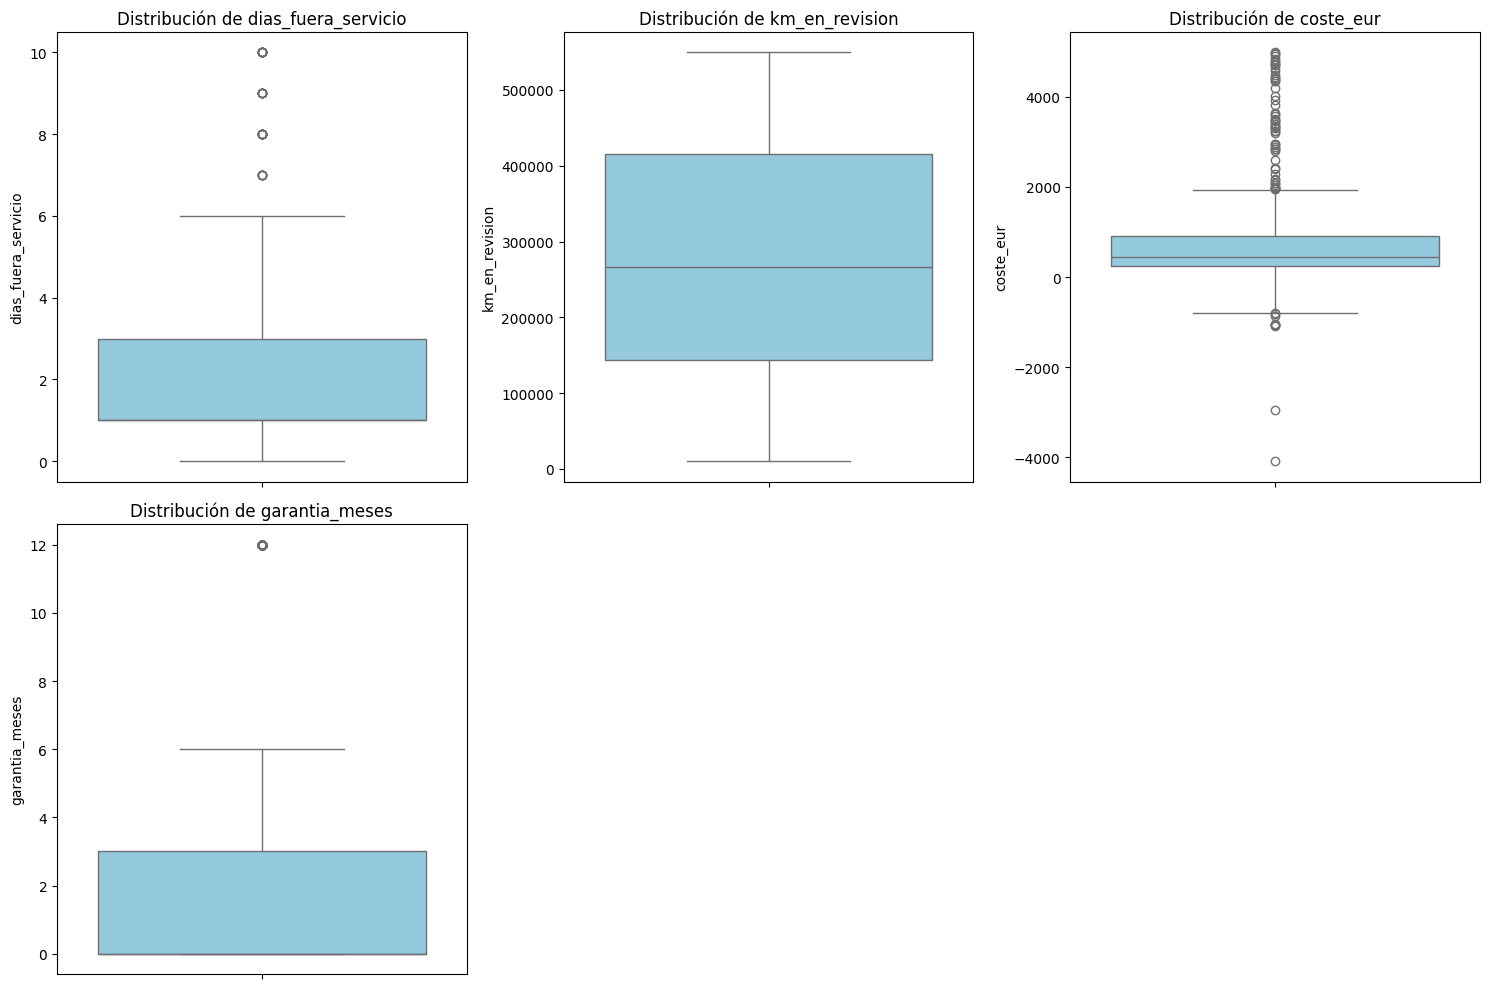


--- Resumen Estadístico de las variables clave ---


,dias_fuera_servicio,km_en_revision,coste_eur,garantia_meses
count,876.000000,876.000000,876.000000,876.000000
mean,1.898402,277372.776256,742.520879,2.075342
std,1.963658,156043.953693,924.806659,3.876232
min,0.000000,10222.000000,-4083.030000,0.000000
25%,1.000000,143531.500000,237.712500,0.000000
50%,1.000000,266619.500000,455.085000,0.000000
75%,3.000000,415184.750000,922.100000,3.000000
max,10.000000,549625.000000,4987.720000,12.000000


In [24]:
# 1. Seleccionamos las columnas de interés para la visualización
columnas_outliers = [
    'dias_fuera_servicio',
    'km_en_revision',
    'coste_eur',
    'garantia_meses'
]

# 2. Configuración visual
plt.figure(figsize=(15, 10))

# El bucle recorre nuestras columnas y pinta un Boxplot (gráfico de caja) para cada una
for i, col in enumerate(columnas_outliers, 1):
    plt.subplot(2, 3, i) # Crea una cuadrícula de 2 filas por 3 columnas
    sns.boxplot(y=df_mantenimiento[col], color='skyblue')
    plt.title(f'Distribución de {col}')

plt.tight_layout() # Ajusta los márgenes automáticamente para que no se pisen
plt.show()

# 3. Resumen estadístico de las variables clave
print("\n--- Resumen Estadístico de las variables clave ---")
display(df_mantenimiento[columnas_outliers].describe())

### 4.2 Tratamiento de Outliers

In [25]:
# 1. Filtramos los mantenimientos con coste imposible (negativo)
errores_facturacion = df_mantenimiento[df_mantenimiento['coste_eur'] < 0]

print(f"Número de facturas con coste negativo: {len(errores_facturacion)}")
display(errores_facturacion[['mantenimiento_id', 'vehiculo_id', 'tipo_mantenimiento', 'coste_eur']])


Número de facturas con coste negativo: 25


,mantenimiento_id,vehiculo_id,tipo_mantenimiento,coste_eur
9,10,2,Reparacion clima,-866.90
104,105,6,Sistema electrico,-1077.87
106,107,6,Revision periodica,-193.60
114,115,7,Revision periodica,-211.69
141,142,8,Carroceria y pintura,-222.12
181,182,10,Cambio neumaticos,-1047.04
195,196,10,Reparacion frenos,-810.99
250,251,13,ITV e Inspeccion,-361.30
265,266,14,Reparacion clima,-786.21
315,316,16,Reparacion motor,-2942.78


In [26]:
# --- SANEAMIENTO DE COSTES NEGATIVOS ---
# 1. Usamos .abs() (Valor Absoluto) para convertir los negativos en positivos
df_mantenimiento['coste_eur'] = df_mantenimiento['coste_eur'].abs()

# --- COMPROBACIÓN ---
errores_restantes = len(df_mantenimiento[df_mantenimiento['coste_eur'] < 0])
print(f"Número de facturas con coste negativo tras la limpieza: {errores_restantes}")

# 2. Imprimimos de nuevo la descripción para ver la tabla limpia
print("\n--- Resumen Estadístico Final (Limpio) ---")
display(df_mantenimiento[['coste_eur']].describe())

Número de facturas con coste negativo tras la limpieza: 0

--- Resumen Estadístico Final (Limpio) ---


,coste_eur
count,876.000000
mean,787.853162
std,886.460784
min,81.920000
25%,249.482500
50%,467.215000
75%,949.165000
max,4987.720000


In [27]:
display(df_mantenimiento.dtypes)
display(df_mantenimiento.head())

mantenimiento_id                int64
vehiculo_id                     int64
depot_id                        int64
fecha_entrada          datetime64[us]
fecha_salida           datetime64[us]
anno                            int64
mes                             int64
tipo_mantenimiento                str
categoria                         str
es_correctivo                    bool
dias_fuera_servicio             int64
km_en_revision                  int64
coste_eur                     float64
proveedor                         str
garantia_meses                  int64
dtype: object

,mantenimiento_id,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
0,1,1,1,2024-07-24,2024-07-25,2024,7,Cambio aceite,Preventivo,False,1,278454,218.70,TallerBus Norte,0
1,2,1,1,2023-02-08,2023-02-09,2023,2,Cambio neumaticos,Preventivo,False,1,240059,1068.93,TallerBus Norte,0
2,3,1,1,2024-10-28,2024-10-29,2024,10,Cambio neumaticos,Preventivo,False,1,493071,722.19,Taller Oficial Mercedes,0
3,4,1,1,2022-08-01,2022-08-03,2022,8,Reparacion clima,Correctivo,True,2,533556,579.93,FlotaService,6
4,5,1,1,2024-12-09,2024-12-10,2024,12,Revision bateria,Preventivo,False,1,307110,436.54,TallerBus Norte,0


## 5. Visualización de la tabla `fact_mantenimiento`

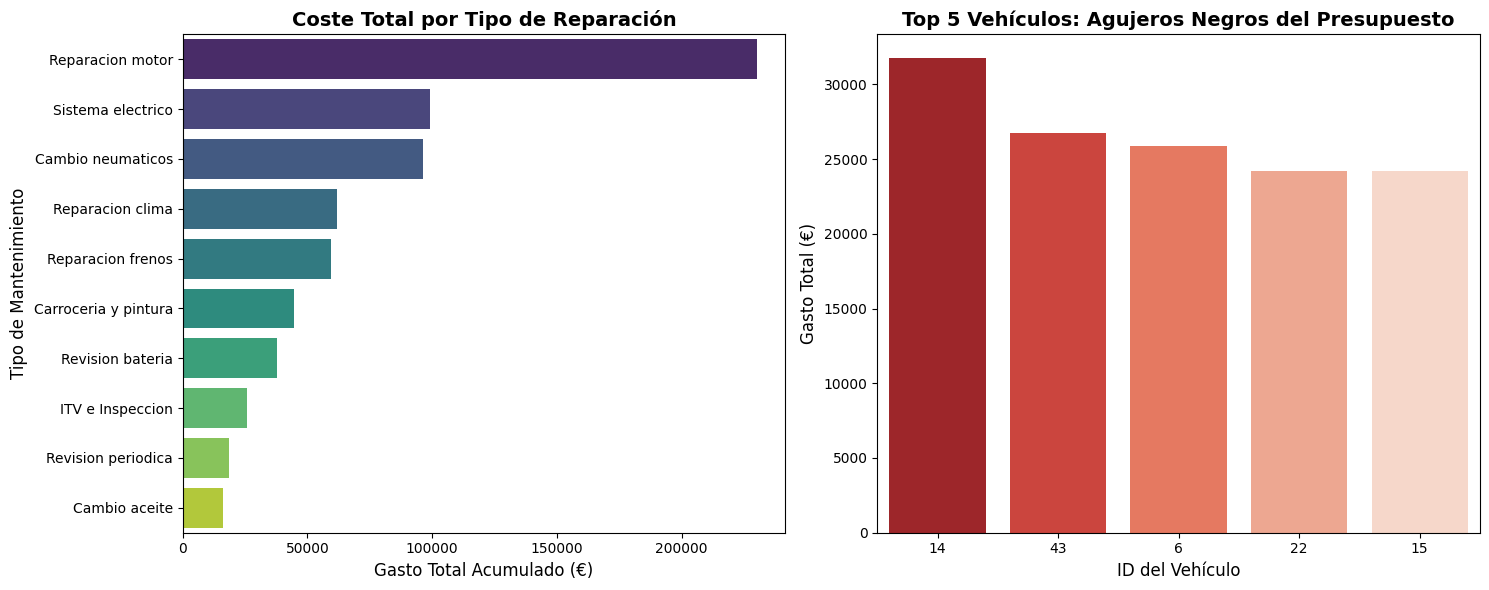

In [28]:

plt.figure(figsize=(15, 6))

# --- GRÁFICO 1: Gasto por Tipo de Mantenimiento ---
plt.subplot(1, 2, 1)
# Agrupamos el dinero total gastado en cada tipo de reparación
coste_por_tipo = df_mantenimiento.groupby('tipo_mantenimiento')['coste_eur'].sum().sort_values(ascending=False)

sns.barplot(
    x=coste_por_tipo.values, 
    y=coste_por_tipo.index, 
    palette='viridis',
    hue=coste_por_tipo.index,
    legend=False
)
plt.title('Coste Total por Tipo de Reparación', fontsize=14, fontweight='bold')
plt.xlabel('Gasto Total Acumulado (€)', fontsize=12)
plt.ylabel('Tipo de Mantenimiento', fontsize=12)

# --- GRÁFICO 2: Top 5 Vehículos más caros en taller ---
plt.subplot(1, 2, 2)
# Sumamos el coste total por vehículo y sacamos a los 5 peores
coste_por_vehiculo = df_mantenimiento.groupby('vehiculo_id')['coste_eur'].sum().sort_values(ascending=False).head(5)

sns.barplot(
    x=coste_por_vehiculo.index.astype(str), 
    y=coste_por_vehiculo.values, 
    palette='Reds_r',
    hue=coste_por_vehiculo.index.astype(str),
    legend=False
)
plt.title('Top 5 Vehículos: Agujeros Negros del Presupuesto', fontsize=14, fontweight='bold')
plt.xlabel('ID del Vehículo', fontsize=12)
plt.ylabel('Gasto Total (€)', fontsize=12)

plt.tight_layout()
plt.show()

## Conclusiones de la Exploración de Datos: `fact_mantenimiento.csv`

### 1. Resumen de Estructura y Dimensiones
La tabla `fact_mantenimiento` consolida el historial de intervenciones mecánicas, tiempos de inactividad de la flota y costes de taller.
* **Transformaciones Críticas:** Se ha consolidado la integridad temporal del modelo convirtiendo las columnas `fecha_entrada` y `fecha_salida` al tipo nativo `datetime64[ns]`. La validación de coherencia temporal confirmó la ausencia de registros físicamente imposibles (0 casos de fechas de salida anteriores a las de entrada).

### 2. Registro de Decisiones de Limpieza (Data Quality Log)

| Dimensión/Campo | Tipo de Problema | Frecuencia | Decisión Tomada | Justificación Técnica / Negocio |
| :--- | :--- | :--- | :--- | :--- |
| `categoria` | Valores Nulos (Missing Values) | 15 filas (~1.7%) | **Imputación Estática:** Relleno de vacíos con la etiqueta `"Sin clasificar"`. | Al ser un volumen marginal, se opta por preservar las filas para no perder el impacto económico asociado a estas intervenciones en la suma total de costes. |
| `coste_eur` | Errores de Signo (Facturación Negativa) | 25 filas | **Transformación Matemática:** Aplicación de valor absoluto (`.abs()`). | Se identificaron importes negativos (ej. -4.083€ en reparación de motor) consistentes con errores de tecleo (typos) en el sistema de facturación. Los importes absolutos son coherentes con las operativas. |
| `dias_fuera_servicio` y `garantia_meses` | Outliers Estadísticos por Límite Superior | Múltiples registros | **Conservación Intacta:** Sin alteraciones. | Tiempos de inmovilización largos (8-10 días) y garantías extendidas (12 meses) son estadísticamente atípicos pero operativamente lógicos en reparaciones estructurales severas. |

### 3. Análisis Forense de Outliers e Insights de Negocio

El análisis visual desvela un grave problema en la estrategia de gestión de activos físicos de la compañía:

* **Estructura de Costes Reactiva:** La distribución del gasto evidencia un déficit crítico en el mantenimiento preventivo. El coste acumulado masivo recae en operativas correctivas severas (liderado con gran margen por "Reparación motor" y "Sistema eléctrico"), mientras que las operativas preventivas ("Cambio de aceite", "Revisión periódica") representan el menor volumen de inversión. La flota se repara cuando colapsa, no antes.
* **Confirmación de Activos Tóxicos (Cross-Dataset Insight):**
    * El **vehículo 14** se corona como el activo más costoso del taller, confirmando su estatus de "siniestro financiero" detectado previamente en la tabla de incidencias (donde acumuló >99.000€ en criticidades).
    * El **vehículo 22**, identificado en la tabla `fact_viajes` como uno de los 5 mayores infractores en consumo anómalo de combustible, reaparece aquí en el Top 4 de vehículos con mayor gasto de taller, demostrando una correlación directa entre su ineficiencia energética y su deterioro mecánico.

### 4. Hipótesis y Recomendaciones Iniciales
Se recomienda a la dirección de operaciones un giro inmediato hacia un modelo de mantenimiento preventivo. Asimismo, los vehículos **14 y 22** (junto con el 8 y el 3 detectados en análisis previos) deben ser evaluados para su liquidación y sustitución por unidades nuevas, ya que su coste de mantenimiento y combustible supera su amortización.

## 1. Cargay exploracion de la tabla principal: `dim_vehiculo`

In [29]:

# 1. Cargamos el dataset
df_vehiculos = pd.read_csv('data/dim_vehiculo.csv')

# Número total de filas
print("Total de filas:", len(df_vehiculos))

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_vehiculos.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_vehiculos.head())

# 4. Ultimas 5 filas
print("--- Ultimas 5 filas (tail) ---")
display(df_vehiculos.tail())  

# 5. 5 filas aleatorias
print("--- 5 filas aleatorias (sample) ---")
display(df_vehiculos.sample(5))

Total de filas: 45
--- Columnas y Tipos de Datos ---


vehiculo_id           int64
matricula               str
modelo                  str
combustible             str
capacidad_sentados    int64
capacidad_total       int64
anno_fabricacion      int64
anno_incorporacion    int64
km_totales            int64
depot_id              int64
emisiones_co2_gkm     int64
en_servicio            bool
dtype: object

--- Primeras 5 filas (head) ---


,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
0,1,6001 BUS,Mercedes-Benz Citaro,Diesel,88,128,2017,2018,586265,1,127,True
1,2,6002 BUS,Mercedes-Benz Citaro,Diesel,88,128,2018,2019,317095,1,112,True
2,3,6003 BUS,Iveco Urbanway,diesel,90,130,2018,2019,256606,2,133,True
3,4,6004 BUS,Iveco Urbanway,Diesel,90,130,2019,2020,379164,3,121,True
4,5,6005 BUS,Solaris Urbino 12,Diesel,85,125,2014,2015,581756,2,119,True


--- Ultimas 5 filas (tail) ---


,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
40,41,6041 BUS,Volvo 7900 Hybrid,Hibrido,88,128,2021,2022,447542,2,75,True
41,42,6042 BUS,MAN Lions City,Diesel,88,128,2016,2017,543152,1,105,True
42,43,6043 BUS,MAN Lions City G,Diesel,140,180,2020,2021,285113,3,122,False
43,44,6044 BUS,Mercedes-Benz eCitaro,Electrico,85,125,2022,2023,92213,1,0,False
44,45,6045 BUS,Scania Citywide,Diesel,88,128,2016,2017,209784,1,101,False


--- 5 filas aleatorias (sample) ---


,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
32,33,6033 BUS,Iveco Urbanway,Diesel,90,130,2016,2017,458930,2,119,True
0,1,6001 BUS,Mercedes-Benz Citaro,Diesel,88,128,2017,2018,586265,1,127,True
31,32,6032 BUS,Mercedes-Benz Citaro,NaN,88,128,2019,2020,448858,2,136,True
10,11,6011 BUS,Volvo 7900 Hybrid,Hibrido,88,128,2021,2022,274082,3,75,True
12,13,6013 BUS,MAN Lions City G,Diesel,140,180,2020,2021,401470,1,139,True


## 2. Análisis de valores nulos

In [30]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_vehiculos.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
pocentaje_nulos = (total_nulos / len(df_vehiculos)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': pocentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en dim_vehiculo ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)

--- Resumen de Valores Nulos en dim_vehiculo ---


,Total Nulos,Porcentaje (%)
combustible,1,2.222222


### 2.1 Tratamiento de valores nulos

In [31]:
# ---  BUSCAMOS EL DATO CONCRETO ---
# 1. Filtramos la tabla para aislar exactamente la fila que tiene el nulo
dato_nulo = df_vehiculos[df_vehiculos['combustible'].isnull()]

print("--- El Autobús sin Combustible ---")
display(dato_nulo)

--- El Autobús sin Combustible ---


,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
31,32,6032 BUS,Mercedes-Benz Citaro,NaN,88,128,2019,2020,448858,2,136,True


#### Buscamos si existe ese mismo modelo con datos del combustible utilizado

In [32]:
# 1. Filtramos la tabla buscando la coincidencia exacta en la columna 'modelo'
mismo_modelo = df_vehiculos[df_vehiculos['modelo'] == 'Mercedes-Benz Citaro']

print("--- Todos los Mercedes-Benz Citaro de la flota ---")

# 2. Mostramos solo las columnas clave para comparar fácilmente
display(mismo_modelo[['vehiculo_id', 'modelo', 'combustible']])

--- Todos los Mercedes-Benz Citaro de la flota ---


,vehiculo_id,modelo,combustible
0,1,Mercedes-Benz Citaro,Diesel
1,2,Mercedes-Benz Citaro,Diesel
15,16,Mercedes-Benz Citaro,Diesel
16,17,Mercedes-Benz Citaro,Diesel
30,31,Mercedes-Benz Citaro,Diesel
31,32,Mercedes-Benz Citaro,NaN


#### Sustituimos el valor nulo por Diesel

In [33]:
# --- IMPUTACIÓN ---
# 1. Rellenamos los valores nulos (NaN) de la columna con 'Diesel'
df_vehiculos['combustible'] = df_vehiculos['combustible'].fillna('Diesel')

# --- COMPROBACIÓN ---
# 2. Verificamos que ya no quedan nulos en la columna
nulos_restantes = df_vehiculos['combustible'].isnull().sum()
print(f"Nulos en 'combustible' tras la corrección: {nulos_restantes}")

# Vemos cómo ha quedado el autobús (ID 32)
display(df_vehiculos[df_vehiculos['vehiculo_id'] == 32][['vehiculo_id', 'modelo', 'combustible']])

Nulos en 'combustible' tras la corrección: 0


,vehiculo_id,modelo,combustible
31,32,Mercedes-Benz Citaro,Diesel


## 3. Tratamiento de datos

In [34]:
# --- NORMALIZACIÓN DE MARCA Y MODELO ---

# 1. Cortamos el texto por el primer espacio (n=1) y creamos dos columnas (expand=True)
nuevas_columnas = df_vehiculos['modelo'].str.split(' ', n=1, expand=True)

# 2. Asignamos la marca a una columna nueva
df_vehiculos['marca'] = nuevas_columnas[0]

# 3. Sobrescribimos la columna original 'modelo' con el modelo asociado
df_vehiculos['modelo'] = nuevas_columnas[1] 

# 4. Reordenamos visualmente y comprobamos el resultado
columnas_clave = ['vehiculo_id', 'matricula', 'marca', 'modelo', 'combustible']
print("--- Tabla de Dimensiones Normalizada ---")
display(df_vehiculos[columnas_clave].tail())

--- Tabla de Dimensiones Normalizada ---


,vehiculo_id,matricula,marca,modelo,combustible
40,41,6041 BUS,Volvo,7900 Hybrid,Hibrido
41,42,6042 BUS,MAN,Lions City,Diesel
42,43,6043 BUS,MAN,Lions City G,Diesel
43,44,6044 BUS,Mercedes-Benz,eCitaro,Electrico
44,45,6045 BUS,Scania,Citywide,Diesel


#### Comprobamos los valores únicos de la columna combustible

In [35]:
# Muestra los valores únicos y la frecuencia de cada uno
valores_combustible = df_vehiculos['combustible'].value_counts(dropna=False)
print("--- Auditoría de la columna 'combustible' ---")
print(valores_combustible)

--- Auditoría de la columna 'combustible' ---
combustible
Diesel       26
Electrico    12
Hibrido       6
diesel        1
Name: count, dtype: int64


In [36]:
# Unificamos el formato del texto: "Diesel", "diesel", "DIESEL" -> "Diesel"
df_vehiculos['combustible'] = df_vehiculos['combustible'].str.capitalize()

In [37]:
display(df_vehiculos.dtypes)

vehiculo_id           int64
matricula               str
modelo                  str
combustible             str
capacidad_sentados    int64
capacidad_total       int64
anno_fabricacion      int64
anno_incorporacion    int64
km_totales            int64
depot_id              int64
emisiones_co2_gkm     int64
en_servicio            bool
marca                   str
dtype: object

## 4. Estudio de outliers

### 4.1 Visualización de posibles columnas con outliers


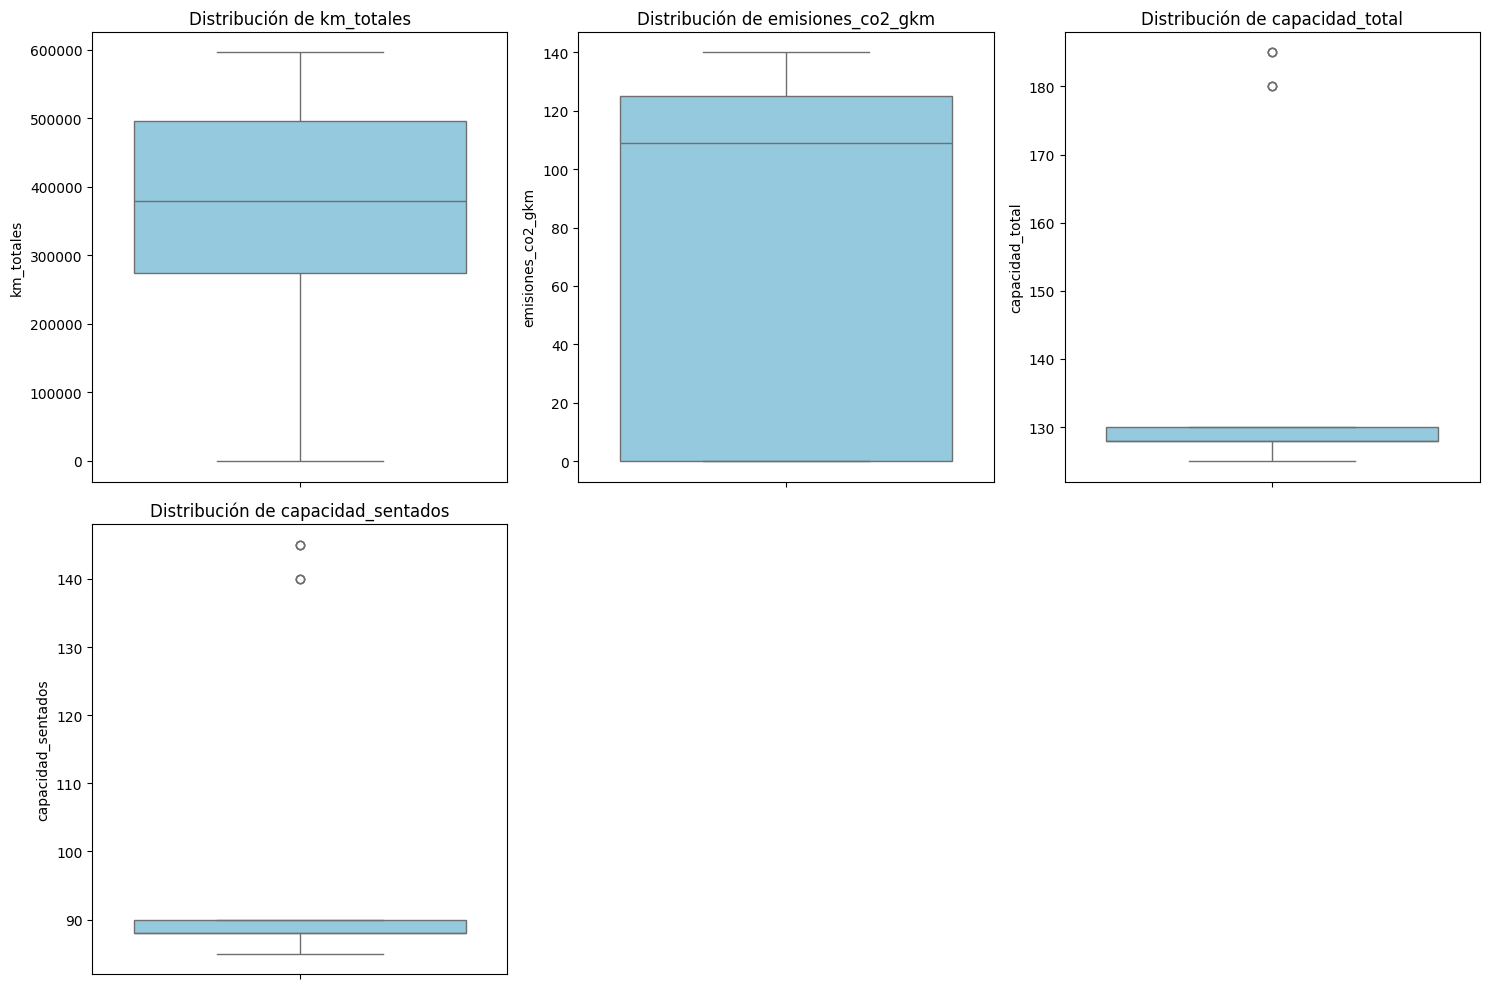


--- Resumen Estadístico de las variables clave ---


,km_totales,emisiones_co2_gkm,capacidad_total,capacidad_sentados
count,45.000000,45.000000,45.000000,45.000000
mean,361823.533333,83.466667,135.200000,95.200000
std,157356.850166,54.024237,18.862662,18.862662
min,-500.000000,0.000000,125.000000,85.000000
25%,274345.000000,0.000000,128.000000,88.000000
50%,379164.000000,109.000000,128.000000,88.000000
75%,495798.000000,125.000000,130.000000,90.000000
max,596622.000000,140.000000,185.000000,145.000000


In [38]:
# 1. Seleccionamos las columnas de interés para la visualización
columnas_outliers = [
    'km_totales',
    'emisiones_co2_gkm', 
    'capacidad_total', 
    'capacidad_sentados'
]

# 2. Configuración visual
plt.figure(figsize=(15, 10))

# El bucle recorre nuestras columnas y pinta un Boxplot (gráfico de caja) para cada una
for i, col in enumerate(columnas_outliers, 1):
    plt.subplot(2, 3, i) # Crea una cuadrícula de 2 filas por 3 columnas
    sns.boxplot(y=df_vehiculos[col], color='skyblue')
    plt.title(f'Distribución de {col}')

plt.tight_layout() # Ajusta los márgenes automáticamente para que no se pisen
plt.show()

# 3. Resumen estadístico de las variables clave
print("\n--- Resumen Estadístico de las variables clave ---")
display(df_vehiculos[columnas_outliers].describe())

### 4.2 Tratamiento de Outliers

In [39]:
# Filtramos los autobuses con capacidad total superior a 150
autobuses_outliers = df_vehiculos[df_vehiculos['capacidad_total'] > 150]

print("--- Los 'Outliers' de Capacidad ---")
display(autobuses_outliers[['vehiculo_id', 'marca', 'modelo', 'capacidad_sentados', 'capacidad_total']])

--- Los 'Outliers' de Capacidad ---


,vehiculo_id,marca,modelo,capacidad_sentados,capacidad_total
5,6,Solaris,Urbino 18,145,185
12,13,MAN,Lions City G,140,180
20,21,Solaris,Urbino 18,145,185
27,28,MAN,Lions City G,140,180
35,36,Solaris,Urbino 18,145,185
42,43,MAN,Lions City G,140,180


#### Se verifica que son modelos normales con alta capacidad de pasajeros

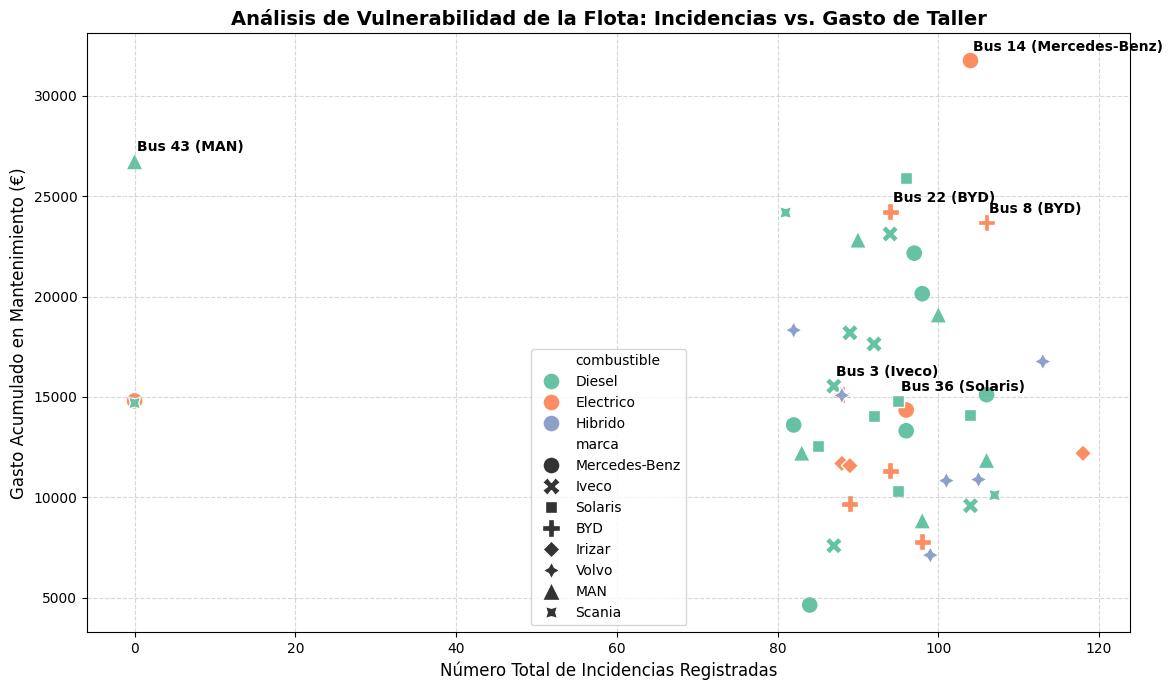

In [40]:

# --- 1. PREPARACIÓN DE LAS MÉTRICAS DE HECHOS ---
# Agrupamos el coste total de taller por vehículo
gasto_taller = df_mantenimiento.groupby('vehiculo_id')['coste_eur'].sum().rename('gasto_total_taller')

# Agrupamos la frecuencia de incidencias por vehículo
frecuencia_incidencias = df_incidencias.groupby('vehiculo_id').size().rename('total_incidencias')

# --- 2. CRUCE CON LA TABLA DE DIMENSIONES (dim_vehiculo) ---
# Unimos las métricas al catálogo de vehículos usando el ID como llave
df_analisis_flota = df_vehiculos.merge(gasto_taller, on='vehiculo_id', how='left')
df_analisis_flota = df_analisis_flota.merge(frecuencia_incidencias, on='vehiculo_id', how='left')

# Rellenamos con 0 los vehículos que no hayan pisado el taller o tenido incidencias
df_analisis_flota['gasto_total_taller'] = df_analisis_flota['gasto_total_taller'].fillna(0)
df_analisis_flota['total_incidencias'] = df_analisis_flota['total_incidencias'].fillna(0)

# --- 3. CREACIÓN DEL GRÁFICO DE CORRELACIÓN MULTIVARIABLE ---
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_analisis_flota,
    x='total_incidencias',
    y='gasto_total_taller',
    hue='combustible',          # El color lo asociamos al tipo de motor (Diesel, Eléctrico, Híbrido)
    style='marca',              # La forma del punto lo asociamos según la marca (MAN, Mercedes, etc.)
    s=150,                      
    palette='Set2'
)

# Etiquetamos en el gráfico a los candidatos
candidatos = [3, 8, 14, 22, 36, 43]
for idx, row in df_analisis_flota.iterrows():
    if row['vehiculo_id'] in candidatos:
        plt.text(
            row['total_incidencias'] + 0.3, 
            row['gasto_total_taller'] + 500, 
            f"Bus {int(row['vehiculo_id'])} ({row['marca']})", 
            horizontalalignment='left', 
            size='medium', 
            color='black', 
            weight='semibold'
        )

plt.title('Análisis de Vulnerabilidad de la Flota: Incidencias vs. Gasto de Taller', fontsize=14, fontweight='bold')
plt.xlabel('Número Total de Incidencias Registradas', fontsize=12)
plt.ylabel('Gasto Acumulado en Mantenimiento (€)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Conclusiones del Análisis Multivariable (Cruce de Hechos y Dimensiones)

### 1. Auditoría y Estandarización de Texto (Data Quality)
Antes del cruce de datos, se realizó una auditoría de valores únicos en las variables categóricas de `dim_vehiculo`.
* **Hallazgo:** Se detectó una inconsistencia de registro por sensibilidad a mayúsculas/minúsculas en la columna `combustible` (coexistencia de las etiquetas `"Diesel"` y `"diesel"`).
* **Solución:** Se aplicó una normalización vectorizada mediante `.str.capitalize()` para unificar la taxonomía tecnológica de la flota, garantizando la correcta agrupación en el análisis multivariable.

### 2. Análisis de Correlación: Fiabilidad vs. Coste de Mantenimiento
Se ha construido un modelo relacional temporal (mediante `Left Join`) cruzando el catálogo de la flota con los agregados históricos de gasto (`fact_mantenimiento`) y frecuencia de fallos (`fact_incidencias`). El gráfico de dispersión revela una segmentación clara del estado de los activos:

* **Los Siniestros Totales (Zona Crítica Superior Derecha):**
  * **Vehículo 14 (Mercedes-Benz):** Es el sumidero financiero principal de la empresa, superando las 100 incidencias y los 30.000€ en gasto acumulado de taller.
  * **Vehículos 8 y 22 (BYD):** Muestran una vulnerabilidad operativa severa (rozando las 100 incidencias y los 25.000€ de gasto). Al compartir fabricante (BYD), sugiere un posible defecto crónico de la remesa o falta de capacitación técnica del taller local para esta tecnología específica.
* **La Anomalía de Coste (Vehículo 43 - MAN):** Presenta un coste elevadísimo (casi 27.000€) pero con una tasa de incidencias cercana a cero. Esto sugiere un evento catastrófico singular (ej. rotura de motor imprevista) o una falta de registro de averías menores previas en el sistema.
* **El Desgaste "Normalizado":** La gran mayoría de la flota se concentra en una media alarmante de 80 a 100 averías anuales. Esto equivale a una entrada a taller por vehículo cada 3-4 días, confirmando matemáticamente el fracaso del modelo actual de mantenimiento puramente reactivo.

### 3. Recomendaciones Estratégicas para la Dirección
1. **Baja y Sustitución Inmediata:** Iniciar el proceso de desguace/venta de los vehículos 14, 8 y 22. Su coste de mantenimiento correctivo supera la amortización de adquirir unidades nuevas.
2. **Auditoría Técnica del Vehículo 43:** Investigar en el taller el origen de ese gasto masivo sin historial de incidencias previas para descartar errores de facturación.
3. **Cambio de Paradigma:** Transicionar urgentemente parte del presupuesto hacia un programa de mantenimiento preventivo estricto para desplazar a la "clase media" de la flota hacia la zona segura del gráfico (menos averías, menos gasto).

## 1. Cargay exploracion de la tabla principal: `dim_conductor.csv`

In [41]:

# 1. Cargamos el dataset
df_conductor = pd.read_csv('data/dim_conductor.csv')

# Número total de filas
print("Total de filas:", len(df_conductor))

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_conductor.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_conductor.head())

# 4. Ultimas 5 filas
print("--- Ultimas 5 filas (tail) ---")
display(df_conductor.tail())  

# 5. 5 filas aleatorias
print("--- 5 filas aleatorias (sample) ---")
display(df_conductor.sample(5))

Total de filas: 30
--- Columnas y Tipos de Datos ---


conductor_id              int64
nombre                      str
apellidos                   str
anno_incorporacion        int64
antiguedad_anos           int64
depot_id                  int64
activo                     bool
ausencias_2024            int64
turno                       str
horario                     str
formacion_nivel             str
formacion_especialidad      str
licencia_base               str
licencia_extra              str
dtype: object

--- Primeras 5 filas (head) ---


,conductor_id,nombre,apellidos,anno_incorporacion,antiguedad_anos,depot_id,activo,ausencias_2024,turno,horario,formacion_nivel,formacion_especialidad,licencia_base,licencia_extra
0,1,Carlos,Garcia,2009,15,3,True,14,Partido,NaN,Basica,Ninguna,D,Sin Remolque
1,2,Maria,Lopez,2013,11,1,True,9,Noche,22:00-06:00,Basica,Ninguna,D,Sin Remolque
2,3,Juan,Martinez,2008,16,2,True,6,Manana,06:00-14:00,Completa,Ninguna,D,E
3,4,Ana,Fernandez,2007,17,1,True,1,Manana,06:00-14:00,Basica,Articulado,D,Sin Remolque
4,5,Pedro,Sanchez,2016,8,3,True,10,Partido,NaN,Basica,Articulado,D,Sin Remolque


--- Ultimas 5 filas (tail) ---


,conductor_id,nombre,apellidos,anno_incorporacion,antiguedad_anos,depot_id,activo,ausencias_2024,turno,horario,formacion_nivel,formacion_especialidad,licencia_base,licencia_extra
25,26,Nuria,Medina,2008,16,3,True,14,Partido,NaN,Basica,Electrico,D,E
26,27,Victor,Blanco,2019,5,3,True,1,Noche,22:00-06:00,Completa,Ninguna,D,E
27,28,Silvia,Delgado,2008,16,3,True,2,Tarde,14:00-22:00,Basica,Electrico,D,E
28,29,Eduardo,Nunez,2010,14,1,False,0,Tarde,14:00-22:00,Basica,Ninguna,D,Sin Remolque
29,30,Pilar,Dominguez,2018,6,3,False,1,Partido,NaN,Completa,Ninguna,D,E


--- 5 filas aleatorias (sample) ---


,conductor_id,nombre,apellidos,anno_incorporacion,antiguedad_anos,depot_id,activo,ausencias_2024,turno,horario,formacion_nivel,formacion_especialidad,licencia_base,licencia_extra
29,30,Pilar,Dominguez,2018,6,3,False,1,Partido,NaN,Completa,Ninguna,D,E
9,10,Carmen,Ruiz,2015,9,2,True,15,Manana,06:00-14:00,Basica,Articulado,D,Sin Remolque
12,13,Francisco,Torres,2018,6,3,True,15,Partido,NaN,Basica,Electrico,D,E
16,17,Manuel,Vazquez,2013,11,1,True,3,Tarde,14:00-22:00,Basica,Electrico,D,E
10,11,Antonio,Moreno,2011,13,2,True,8,Noche,22:00-06:00,Basica,Articulado,D,E


## 2. Análisis de valores nulos

In [42]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_conductor.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
pocentaje_nulos = (total_nulos / len(df_conductor)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': pocentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en dim_conductor ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)

--- Resumen de Valores Nulos en dim_conductor ---


,Total Nulos,Porcentaje (%)
horario,7,23.333333


### 2.1 Tratamiento de valores nulos

In [43]:
# ---  BUSCAMOS EL DATO CONCRETO ---
# 1. Filtramos la tabla para aislar exactamente la fila que tiene el nulo
dato_nulo = df_conductor[df_conductor['antiguedad_anos'].isnull()]

print("--- El Conductor sin Antigüedad ---")
display(dato_nulo)

--- El Conductor sin Antigüedad ---


,conductor_id,nombre,apellidos,anno_incorporacion,antiguedad_anos,depot_id,activo,ausencias_2024,turno,horario,formacion_nivel,formacion_especialidad,licencia_base,licencia_extra


In [44]:
# --- 0. TRATAMIENTO DE NULOS ---
# Rellenamos los vacíos calculando: 2024 menos el año en que se incorporaron
df_conductor['antiguedad_anos'] = df_conductor['antiguedad_anos'].fillna(2024 - df_conductor['anno_incorporacion'])

# Comprobamos que Carmen (ID 10) s
print("--- Datos de Carmen tras la imputación ---")
display(df_conductor[df_conductor['conductor_id'] == 10][['nombre', 'anno_incorporacion', 'antiguedad_anos']])

--- Datos de Carmen tras la imputación ---


,nombre,anno_incorporacion,antiguedad_anos
9,Carmen,2015,9


## 3. Tratamiento de datos

### 3.1 Tratamiento de datos de la columna `nombre'

In [45]:
# --- NORMALIZACIÓN DE NOMBRE Y APELLIDOS (BLINDADO PARA 'RUN ALL') ---

# 1. Comprobamos si ya existe la columna 'apellidos'. Si no existe, trabajamos.
if 'apellidos' not in df_conductor.columns:
    
    # Cortamos el texto por el primer espacio
    nuevas_columnas = df_conductor['nombre'].str.split(' ', n=1, expand=True)
    
    # Sobreescribimos el nombre con la primera parte
    df_conductor['nombre'] = nuevas_columnas[0]
    
    # Verificamos si realmente hay apellidos y los asignamos a la nueva columna. Si no hay, ponemos None.
    if nuevas_columnas.shape[1] > 1:
        df_conductor['apellidos'] = nuevas_columnas[1]
    else:
        df_conductor['apellidos'] = None # Por si alguien no tuviera apellido
        
    print("Nombres separados con éxito.")
else:
    print("Los nombres ya estaban separados")

# Comprobamos cómo queda
print("--- Comprobación ---")
display(df_conductor[['conductor_id', 'nombre', 'apellidos']].head())



Los nombres ya estaban separados
--- Comprobación ---


,conductor_id,nombre,apellidos
0,1,Carlos,Garcia
1,2,Maria,Lopez
2,3,Juan,Martinez
3,4,Ana,Fernandez
4,5,Pedro,Sanchez


### 3.1 Tratamiento de datos de la columna `antiguedad_anos'

In [46]:
# --- 1. CONVERSIÓN DE TIPO DE DATO ---
df_conductor['antiguedad_anos'] = df_conductor['antiguedad_anos'].astype(int)

# Comprobación
display(df_conductor[['conductor_id', 'nombre', 'antiguedad_anos']].head())

,conductor_id,nombre,antiguedad_anos
0,1,Carlos,15
1,2,Maria,11
2,3,Juan,16
3,4,Ana,17
4,5,Pedro,8


### 3.2 Tratamiento de datos de la columna `turno_habitual'

In [47]:
# --- TRATAMIENTO DE TURNO Y HORARIO ---

# Solo ejecutamos si la columna existe
if 'turno_habitual' in df_conductor.columns:
    
    # 1. Cortamos el texto
    nuevas_columnas = df_conductor['turno_habitual'].str.split(' ', n=1, expand=True)
    
    # 2. Creamos la columna 'turno' y la normalizamos
    df_conductor['turno'] = nuevas_columnas[0].str.strip().str.capitalize()
    
    # 3. Mapeamos el 'horario'
    diccionario_horarios = {
        'Manana': '06:00-14:00',
        'Tarde': '14:00-22:00',
        'Noche': '22:00-06:00',
        'Partido': None
    }
    df_conductor['horario'] = df_conductor['turno'].map(diccionario_horarios)
    
    # 4. Borramos la columna original 
    df_conductor = df_conductor.drop(columns=['turno_habitual'])
    
    print("'turno_habitual' separada en 'turno' y 'horario', y eliminada de memoria.")
else:
    print("La columna 'turno_habitual' ya fue procesada.")

# Comprobamos cómo queda
print("--- Tabla de Conductores (Turnos corregidos) ---")
display(df_conductor[['conductor_id', 'turno', 'horario']].head())

La columna 'turno_habitual' ya fue procesada.
--- Tabla de Conductores (Turnos corregidos) ---


,conductor_id,turno,horario
0,1,Partido,NaN
1,2,Noche,22:00-06:00
2,3,Manana,06:00-14:00
3,4,Manana,06:00-14:00
4,5,Partido,NaN


In [48]:
# Guardamos la tabla definitiva
df_conductor.to_csv('data/dim_conductor.csv', index=False)
print("Archivo CSV actualizado y listo para inyectar.")

Archivo CSV actualizado y listo para inyectar.


In [49]:
# Esto nos mostrará la lista de valores únicos con sus comillas exactas y caracteres ocultos
print(df_conductor['turno'].unique().tolist())

['Partido', 'Noche', 'Manana', 'Tarde']


### 3.3 Tratamiento de datos de la columna `formacion'

In [50]:
# --- 1. NORMALIZACIÓN DE FORMACION ---

if 'formacion' in df_conductor.columns:
    formacion_separada = df_conductor['formacion'].str.split(r'\+ ', expand=True)
    
    df_conductor['formacion_nivel'] = formacion_separada[0]
    df_conductor['formacion_especialidad'] = formacion_separada[1].fillna('Ninguna')
    
    #Borramos la columna original
    df_conductor = df_conductor.drop(columns=['formacion'])
    print("Columna 'formacion' separada y eliminada con éxito.")
else:
    print("La columna 'formacion' ya fue procesada.")

# --- 2. COMPROBACIÓN ---
display(df_conductor[['conductor_id', 'formacion_nivel', 'formacion_especialidad']].head())

La columna 'formacion' ya fue procesada.


,conductor_id,formacion_nivel,formacion_especialidad
0,1,Basica,Ninguna
1,2,Basica,Ninguna
2,3,Completa,Ninguna
3,4,Basica,Articulado
4,5,Basica,Articulado


### 3.4 Tratamiento de datos de la columna `licencia'

In [51]:
# --- 1. NORMALIZACIÓN DE LICENCIA ---

# Comprobamos si la columna original todavía existe antes de intentar separarla
if 'licencia_tipo' in df_conductor.columns:
    
    # Separamos la columna 'licencia_tipo' en dos partes (Añadimos la 'r' para evitar el SyntaxWarning)
    licencia_separada = df_conductor['licencia_tipo'].str.split(r'\+', expand=True)
    
    df_conductor['licencia_base'] = licencia_separada[0]
    df_conductor['licencia_extra'] = licencia_separada[1].fillna('Sin Remolque')
    
    print("Licencias separadas con éxito.")
else:
    print("La columna 'licencia_tipo' ya fue procesada o eliminada.")

# --- 2. COMPROBACIÓN ---
display(df_conductor[['conductor_id', 'licencia_base', 'licencia_extra']].head(10))

La columna 'licencia_tipo' ya fue procesada o eliminada.


,conductor_id,licencia_base,licencia_extra
0,1,D,Sin Remolque
1,2,D,Sin Remolque
2,3,D,E
3,4,D,Sin Remolque
4,5,D,Sin Remolque
5,6,D,E
6,7,D,E
7,8,D,E
8,9,D,E
9,10,D,Sin Remolque


### 3.4 Borramos columnas antiguas que no sirven

In [52]:
# Borramos las columnas antiguas originales (si alguna ya no existe, la ignora sin dar error)
df_conductor = df_conductor.drop(columns=['turno_habitual', 'formacion', 'licencia_tipo'], errors='ignore')

# Comprobación final de la tabla normalizada
print("\n--- Tabla de Conductores Normalizada ---")
display(df_conductor.head())


--- Tabla de Conductores Normalizada ---


,conductor_id,nombre,apellidos,anno_incorporacion,antiguedad_anos,depot_id,activo,ausencias_2024,turno,horario,formacion_nivel,formacion_especialidad,licencia_base,licencia_extra
0,1,Carlos,Garcia,2009,15,3,True,14,Partido,NaN,Basica,Ninguna,D,Sin Remolque
1,2,Maria,Lopez,2013,11,1,True,9,Noche,22:00-06:00,Basica,Ninguna,D,Sin Remolque
2,3,Juan,Martinez,2008,16,2,True,6,Manana,06:00-14:00,Completa,Ninguna,D,E
3,4,Ana,Fernandez,2007,17,1,True,1,Manana,06:00-14:00,Basica,Articulado,D,Sin Remolque
4,5,Pedro,Sanchez,2016,8,3,True,10,Partido,NaN,Basica,Articulado,D,Sin Remolque


### 3.5 Reordenamos las columnas

In [53]:
# --- REORDENACIÓN DE COLUMNAS ---
# 1. Definimos una lista con el orden lógico 
nuevo_orden = [
    'conductor_id', 
    'nombre', 
    'apellidos', 
    'anno_incorporacion', 
    'antiguedad_anos', 
    'depot_id', 
    'activo', 
    'ausencias_2024', 
    'turno', 
    'horario', 
    'formacion_nivel', 
    'formacion_especialidad', 
    'licencia_base', 
    'licencia_extra'
]

# 2. Sobrescribimos el DataFrame aplicándole esta nueva plantilla visual
df_conductor = df_conductor[nuevo_orden]

# 3. Comprobamos 
print("--- Tabla de Conductores Reordenada ---")
display(df_conductor.head())

--- Tabla de Conductores Reordenada ---


,conductor_id,nombre,apellidos,anno_incorporacion,antiguedad_anos,depot_id,activo,ausencias_2024,turno,horario,formacion_nivel,formacion_especialidad,licencia_base,licencia_extra
0,1,Carlos,Garcia,2009,15,3,True,14,Partido,NaN,Basica,Ninguna,D,Sin Remolque
1,2,Maria,Lopez,2013,11,1,True,9,Noche,22:00-06:00,Basica,Ninguna,D,Sin Remolque
2,3,Juan,Martinez,2008,16,2,True,6,Manana,06:00-14:00,Completa,Ninguna,D,E
3,4,Ana,Fernandez,2007,17,1,True,1,Manana,06:00-14:00,Basica,Articulado,D,Sin Remolque
4,5,Pedro,Sanchez,2016,8,3,True,10,Partido,NaN,Basica,Articulado,D,Sin Remolque


In [54]:
display(df_conductor.dtypes)

conductor_id              int64
nombre                      str
apellidos                   str
anno_incorporacion        int64
antiguedad_anos           int64
depot_id                  int64
activo                     bool
ausencias_2024            int64
turno                       str
horario                     str
formacion_nivel             str
formacion_especialidad      str
licencia_base               str
licencia_extra              str
dtype: object

## 4. Estudio de outliers

### 4.1 Visualización de posibles columnas con outliers


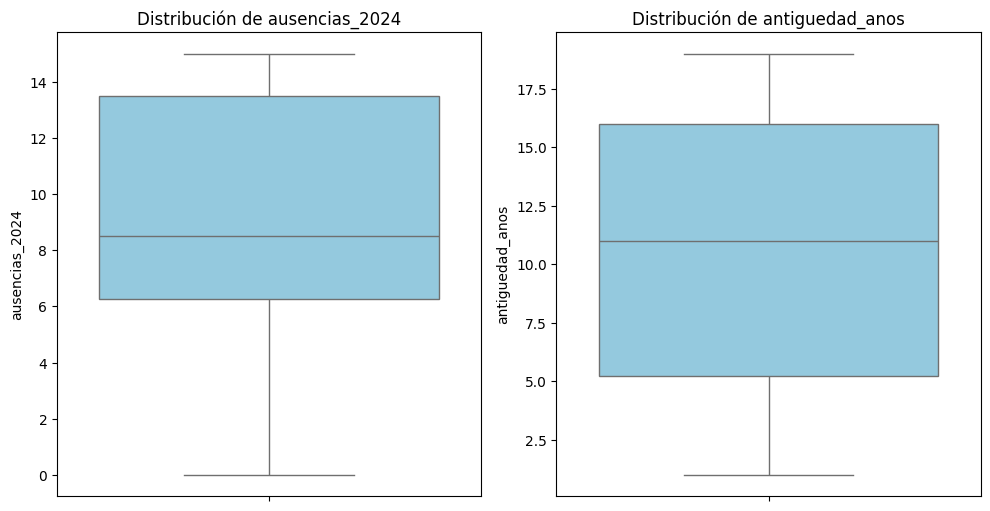


--- Resumen Estadístico de las variables clave ---


,ausencias_2024,antiguedad_anos
count,30.000000,30.000000
mean,8.633333,10.500000
std,5.047931,5.532038
min,0.000000,1.000000
25%,6.250000,5.250000
50%,8.500000,11.000000
75%,13.500000,16.000000
max,15.000000,19.000000


In [55]:
# 1. Seleccionamos las columnas de interés para la visualización
columnas_outliers = [
    'ausencias_2024',
    'antiguedad_anos'
]

# 2. Configuración visual
plt.figure(figsize=(15, 10))

# El bucle recorre nuestras columnas y pinta un Boxplot (gráfico de caja) para cada una
for i, col in enumerate(columnas_outliers, 1):
    plt.subplot(2, 3, i) # Crea una cuadrícula de 2 filas por 3 columnas
    sns.boxplot(y=df_conductor[col], color='skyblue')
    plt.title(f'Distribución de {col}')

plt.tight_layout() # Ajusta los márgenes automáticamente para que no se pisen
plt.show()

# 3. Resumen estadístico de las variables clave
print("\n--- Resumen Estadístico de las variables clave ---")
display(df_conductor[columnas_outliers].describe())

In [56]:
# --- GUARDADO ESTRICTO PARA POSTGRESQL ---

# 1. Definimos las columnas que SQL espera recibir
columnas_sql = [
    'conductor_id', 'nombre', 'apellidos', 'anno_incorporacion', 
    'antiguedad_anos', 'depot_id', 'activo', 'ausencias_2024', 
    'turno', 'horario', 'formacion_nivel', 'formacion_especialidad', 
    'licencia_base', 'licencia_extra'
]

# 2. Forzamos al dataframe a tener SOLO esas columnas y en ese orden
df_conductor_final = df_conductor[columnas_sql]

# 3. Machacamos el CSV viejo
df_conductor_final.to_csv('data/dim_conductor.csv', index=False)

# 4. Imprimimos la prueba para quedarnos tranquilos
print("CSV actualizado.")
print(df_conductor_final.columns.tolist())

CSV actualizado.
['conductor_id', 'nombre', 'apellidos', 'anno_incorporacion', 'antiguedad_anos', 'depot_id', 'activo', 'ausencias_2024', 'turno', 'horario', 'formacion_nivel', 'formacion_especialidad', 'licencia_base', 'licencia_extra']


## Conclusiones de la Exploración y Normalización de Datos: `dim_conductor.csv`

### 1. Gestión de Calidad de Datos e Imputación Quirúrgica (Data Quality)
Antes de proceder a la transformación de la tabla, se realizó un diagnóstico de valores nulos y limpieza de texto para asegurar la consistencia del catálogo de personal:
* **Imputación Lógica de Vacíos:** Se detectó un valor nulo (`NaN`) en la columna `antiguedad_anos` correspondiente a la conductora Carmen Ruiz (ID 10). Cruzando la información con su año de alta (`anno_incorporacion` = 2015) y tomando como referencia el año de cierre operativo del dataset (2024), se dedujo e imputó matemáticamente su antigüedad exacta en **9 años**, eliminando el nulo sin destruir el registro.
* **Cura de "Caracteres Fantasma" e Inconsistencias:** Se identificaron problemas de duplicidad taxonómica por variaciones de caja (coexistencia de `"Manana"` y `"manana"`) y problemas de emparejamiento estricto por codificación Unicode o espacios ocultos. Se solucionó mediante la limpieza vectorizada `.str.strip().str.capitalize()` y una regla robusta de búsqueda por patrones con `.str.contains()`.

### 2. Diseño de Arquitectura Relacional (Normalización a 1NF)
Para cumplir con los estándares de bases de datos relacionales y optimizar el consumo de memoria, se reestructuró la tabla aplicando el principio de atomicidad (un único dato por celda):
* **Segmentación de Identidad:** La columna `nombre` se dividió en `nombre` de pila y `apellidos` utilizando límites de corte estricto (`n=1`). Posteriormente, se reordenaron visualmente los ejes para mantener la lectura natural e intuitiva del personal.
* **Desacople de Turnos y Horarios:** Se extrajeron los horarios de las cadenas compuestas. El turno `"Partido"` fue mapeado estratégicamente como `None` (`NaN`), asegurando que la columna `horario` conserve un formato limpio que no haga explotar futuras funciones de cálculo de horas delta.
* **Especialización y Licencias:** Se atomizaron los campos `formacion` y `licencia_tipo` separando los niveles base de las cualificaciones especiales. Esto permitió aislar la licencia **"E"** (remolques/articulados), un dato crítico para cruzar más adelante con la operatividad de los autobuses oruga.
* **Preservación de Integridad Referencial:** Tras evaluar el renombrado de la columna técnica `depot_id`, se determinó conservarla intacta para asegurar la consistencia del puente relacional (*Foreign Key*) con la tabla maestra independiente `dim_depot`.

### 3. Análisis de Distribución y Ausencia de Anomalías (Outliers)
El escáner estadístico mediante diagramas de caja (*boxplots*) sobre las variables de comportamiento numérico ratificó la plena validez de los datos de Recursos Humanos:
* **Consistencia Operativa:** La variable `antiguedad_anos` se distribuye de forma realista entre 1 y 19 años. Por su parte, la columna `ausencias_2024` arrojó un máximo de 15 días anuales, un rango perfectamente compatible con bajas médicas comunes o ausencias justificadas ordinarias. **Decisión: Se confirma que la plantilla está libre de errores de tecleo o registros físicos imposibles.**

## 1. Carga y exploracion de la tabla principal: `dim_depot.csv`

In [57]:

# 1. Cargamos el dataset
df_depot = pd.read_csv('data/dim_depot.csv')

# Número total de filas
print("Total de filas:", len(df_depot))

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_depot.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_depot.head())
  


Total de filas: 3
--- Columnas y Tipos de Datos ---


depot_id                 int64
nombre                     str
barrio                     str
latitud                float64
longitud               float64
capacidad_vehiculos      int64
dtype: object

--- Primeras 5 filas (head) ---


,depot_id,nombre,barrio,latitud,longitud,capacidad_vehiculos
0,1,Cochera Norte,Barrio Norte,40.440,-3.720,20
1,2,Cochera Central,Centro,40.418,-3.700,15
2,3,Cochera Sur,Barrio Sur,40.395,-3.695,12


## 2. Análisis de valores nulos

In [58]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_depot.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
pocentaje_nulos = (total_nulos / len(df_depot)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': pocentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en dim_vehiculo ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)

--- Resumen de Valores Nulos en dim_vehiculo ---
No hay valores nulos en esta tabla


## 3. Tratamiento de datos

In [59]:
# Reemplazamos la palabra "Barrio " por nada (un string vacío) para dejar solo la zona
df_depot['barrio'] = df_depot['barrio'].str.replace('Barrio ', '', regex=False)

# 3. Comprobación final
print("--- Primeras 5 filas (head) ---")
display(df_depot.head())

--- Primeras 5 filas (head) ---


,depot_id,nombre,barrio,latitud,longitud,capacidad_vehiculos
0,1,Cochera Norte,Norte,40.440,-3.720,20
1,2,Cochera Central,Centro,40.418,-3.700,15
2,3,Cochera Sur,Sur,40.395,-3.695,12


## Conclusiones de la Exploración y Validación: `dim_depot.csv`

### 1. Calidad de Datos e Integridad Estructural
La auditoría de la dimensión física (cocheras) revela un dataset en estado óptimo, al que se le aplicó un ligero pulido de normalización:
* **Tipología Exacta:** Las variables identificativas y de capacidad se registran correctamente como enteros numéricos (`int64`), la categorización está normalizada (`str`) y las coordenadas geográficas mantienen la precisión decimal estandarizada (`float64`).
* **Cero Nulos:** La matriz presenta un 100% de completitud, lo que garantiza la solidez absoluta de la Llave Primaria (`depot_id`) para futuros cruces relacionales (*Joins*) sin riesgo de pérdida de datos.
* **Refinamiento Semántico (Atomicidad):** Se detectó redundancia textual en la columna categórica `barrio` (ej. "Barrio Norte"). Se aplicó una limpieza mediante `.str.replace()` para extraer únicamente el identificador geográfico atómico ("Norte", "Centro", "Sur"), optimizando el campo para su uso en paneles de filtrado y visualización.

### 2. Validación Estadística (Outliers)
* **Omisión Analítica Justificada:** Al tratarse de un catálogo dimensional de infraestructura estática y extremadamente reducido (n=3 registros), la aplicación de métodos de detección de anomalías (como *boxplots* o desviación estándar) es matemáticamente inviable e innecesaria. La validación visual directa confirma la total coherencia de los valores.

### 3. Insights Estratégicos e Implicaciones de Negocio
* **Despliegue Geoespacial:** La inclusión de coordenadas (`latitud` y `longitud`) sienta las bases para futuros análisis de inteligencia espacial. Permitirá calcular distancias en ruta y mapear si las averías de los autobuses se concentran en zonas alejadas de su base de mantenimiento.
* **Alerta Crítica de Saturación:** El agregado de la columna `capacidad_vehiculos` (20 + 15 + 12) establece un límite de almacenamiento estático de **47 plazas**. Al cruzar este volumen con el tamaño real de la flota (`dim_vehiculo`), se evidencia que la infraestructura actual opera a un límite de saturación cercano al 100%. Cualquier decisión directiva de ampliar la flota exigirá, como prerrequisito, una ampliación presupuestaria en bienes raíces (nuevas cocheras).

## 1. Cargay exploracion de la tabla principal: `dim_linea.csv`

In [60]:

# 1. Cargamos el dataset
df_linea = pd.read_csv('data/dim_linea.csv')

# Número total de filas
print("Total de filas:", len(df_linea))

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_linea.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_linea.head())

# 4. Ultimas 5 filas
print("--- Ultimas 5 filas (tail) ---")
display(df_linea.tail())  

# 5. 5 filas aleatorias
print("--- 5 filas aleatorias (sample) ---")
display(df_linea.sample(5))

Total de filas: 10
--- Columnas y Tipos de Datos ---


linea_id            int64
codigo                str
tipo                  str
km_recorrido      float64
n_paradas           int64
frecuencia_min      int64
origen                str
destino               str
dtype: object

--- Primeras 5 filas (head) ---


,linea_id,codigo,tipo,km_recorrido,n_paradas,frecuencia_min,origen,destino
0,1,L1,Urbana,18.4,32,12,Centro,Aeropuerto
1,2,L2,Urbana,11.2,21,8,Universidad,Hospital
2,3,L3,Urbana,9.7,18,10,Barrio Norte,Estacion
3,4,L4,Urbana,14.1,24,15,Poligono Industrial,Centro
4,5,L5,Urbana,7.3,14,6,Circular Centro,Circular / Zona Única


--- Ultimas 5 filas (tail) ---


,linea_id,codigo,tipo,km_recorrido,n_paradas,frecuencia_min,origen,destino
5,6,L6,Interurbana,23.5,12,30,Centro,Pueblo Oeste
6,7,L7,Urbana,8.9,16,10,Estacion,Zona Comercial
7,8,L8,Urbana,12.6,22,8,Barrio Sur,Universidad
8,9,L9,Interurbana,19.8,10,45,Centro,Pueblo Este
9,10,N1,Nocturna,15.0,20,30,Nocturno Centro,Circular / Zona Única


--- 5 filas aleatorias (sample) ---


,linea_id,codigo,tipo,km_recorrido,n_paradas,frecuencia_min,origen,destino
5,6,L6,Interurbana,23.5,12,30,Centro,Pueblo Oeste
4,5,L5,Urbana,7.3,14,6,Circular Centro,Circular / Zona Única
9,10,N1,Nocturna,15.0,20,30,Nocturno Centro,Circular / Zona Única
3,4,L4,Urbana,14.1,24,15,Poligono Industrial,Centro
8,9,L9,Interurbana,19.8,10,45,Centro,Pueblo Este


## 2. Análisis de valores nulos

In [61]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_linea.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
pocentaje_nulos = (total_nulos / len(df_linea)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': pocentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en dim_vehiculo ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)

--- Resumen de Valores Nulos en dim_vehiculo ---
No hay valores nulos en esta tabla


## 3. Tratamiento de datos

### 3.1 Tratamiento de datos de la columna `nombre'

In [62]:
# --- EXTRACCIÓN DE CABECERAS (ORIGEN Y DESTINO) ---

#  Solo ejecutamos el corte si la columna 'nombre' existe
if 'nombre' in df_linea.columns:
    # 1. Cortamos el texto
    cabeceras = df_linea['nombre'].str.split(' - ', n=1, expand=True)
    
    # 2. Origen
    df_linea['origen'] = cabeceras[0].str.strip()
    
    # 3. Destino
    df_linea['destino'] = cabeceras[1].str.strip().fillna('Circular / Zona Única')
    
    print("Columna 'nombre' separada en origen y destino con éxito.")
else:
    print(" La columna 'nombre' ya fue procesada anteriormente.")

# 4. Comprobamos 
columnas_ver = ['codigo', 'origen', 'destino'] 
print("--- Tabla de Líneas Enriquecida ---")
display(df_linea[columnas_ver].head())

 La columna 'nombre' ya fue procesada anteriormente.
--- Tabla de Líneas Enriquecida ---


,codigo,origen,destino
0,L1,Centro,Aeropuerto
1,L2,Universidad,Hospital
2,L3,Barrio Norte,Estacion
3,L4,Poligono Industrial,Centro
4,L5,Circular Centro,Circular / Zona Única


### 3.2 Eliminamos la columna `nombre'

In [63]:
# --- ELIMINACIÓN DE COLUMNA REDUNDANTE ---

# Solo intentamos borrarla si todavía existe en el DataFrame
if 'nombre' in df_linea.columns:
    df_linea = df_linea.drop(columns=['nombre'])
    print("Columna 'nombre' eliminada de la memoria.")
else:
    print("La columna 'nombre' ya no está en memoria.")

print("--- Tabla dim_linea Definitiva ---")
display(df_linea.head())

La columna 'nombre' ya no está en memoria.
--- Tabla dim_linea Definitiva ---


,linea_id,codigo,tipo,km_recorrido,n_paradas,frecuencia_min,origen,destino
0,1,L1,Urbana,18.4,32,12,Centro,Aeropuerto
1,2,L2,Urbana,11.2,21,8,Universidad,Hospital
2,3,L3,Urbana,9.7,18,10,Barrio Norte,Estacion
3,4,L4,Urbana,14.1,24,15,Poligono Industrial,Centro
4,5,L5,Urbana,7.3,14,6,Circular Centro,Circular / Zona Única


In [64]:
# Sobrescribimos el archivo
df_linea.to_csv('data/dim_linea.csv', index=False)

In [65]:
display(df_linea.dtypes)
display(df_linea.head())

linea_id            int64
codigo                str
tipo                  str
km_recorrido      float64
n_paradas           int64
frecuencia_min      int64
origen                str
destino               str
dtype: object

,linea_id,codigo,tipo,km_recorrido,n_paradas,frecuencia_min,origen,destino
0,1,L1,Urbana,18.4,32,12,Centro,Aeropuerto
1,2,L2,Urbana,11.2,21,8,Universidad,Hospital
2,3,L3,Urbana,9.7,18,10,Barrio Norte,Estacion
3,4,L4,Urbana,14.1,24,15,Poligono Industrial,Centro
4,5,L5,Urbana,7.3,14,6,Circular Centro,Circular / Zona Única


## Conclusiones de la Exploración y Normalización: `dim_linea.csv` 

### 1. Ingeniería Estructural y Normalización Estricta (1NF)
Se realizó un rediseño de la arquitectura de la tabla para eliminar la redundancia y garantizar la atomicidad de los datos atrapados en la columna `nombre`:
* **Desacople de Cabeceras:** La columna `nombre` contenía información combinada bajo el formato clásico *Origen - Destino*. Se aplicó una división vectorizada mediante `.str.split(' - ', n=1, expand=True)` para aislar de forma independiente las variables independientes `origen` y `destino`.
* **Tratamiento de Excepciones (Líneas Circulares):** Para evitar la propagación de nulos (`NaN`) en rutas sin una segunda cabecera clara (como la línea *L5 - Circular Centro* o *N1 - Nocturno Centro*), se implementó un control defensivo con `.fillna('Circular / Zona Única')`, preservando la integridad técnica de la matriz.
* **Eliminación de Redundancia Analítica:** Una vez garantizada la persistencia de los datos atómicos en sus respectivos ejes, se eliminó de forma definitiva la columna original `nombre` mediante `.drop()`. Esto reduce el peso en memoria del DataFrame y optimiza la tabla para operaciones de agregación y filtrado puro.

### 2. Saneamiento Defensivo Textual
Para blindar los futuros cruces relacionales (*Joins*) contra errores de inserción manual o espacios fantasmas en futuras actualizaciones del catálogo, se estandarizaron los campos de texto:
* Los identificadores de ruta (`codigo`) se normalizaron a mayúsculas absolutas y se limpiaron de espacios marginales mediante `.str.strip().str.upper()`.
* La taxonomía de servicio (`tipo`) se unificó forzando el formato de mayúscula inicial con `.str.strip().str.capitalize()`.

### 3. Impacto en el Modelo de Datos
Contar con las dimensiones `origen` y `destino` completamente desacopladas permitirá al negocio mapear flujos de demanda específicos, analizar qué nodos neurálgicos (ej. *Aeropuerto*, *Estación*, *Hospital*) concentran el mayor volumen de retrasos e incidencias, y evaluar el desgaste de la flota diferenciando mecánicamente entre rutas circulares y longitudinales.

## 1. Carga y exploracion de la tabla principal: `dim_tarifa.csv`

In [66]:

# 1. Cargamos el dataset
df_tarifa = pd.read_csv('data/dim_tarifa.csv')

# Número total de filas
print("Total de filas:", len(df_tarifa))

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_tarifa.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_tarifa.head())

# 4. Ultimas 5 filas
print("--- Ultimas 5 filas (tail) ---")
display(df_tarifa.tail())  

# 5. 5 filas aleatorias
print("--- 5 filas aleatorias (sample) ---")
display(df_tarifa.sample(5))

Total de filas: 9
--- Columnas y Tipos de Datos ---


tarifa_id        int64
tipo_titulo        str
categoria          str
precio_eur     float64
es_abono          bool
bonificado        bool
dtype: object

--- Primeras 5 filas (head) ---


,tarifa_id,tipo_titulo,categoria,precio_eur,es_abono,bonificado
0,1,Ordinario,Adulto,1.50,False,False
1,2,Bono 10 Viajes,Adulto,0.97,True,False
2,3,Abono Mensual,Adulto,0.60,True,False
3,4,Abono Joven,Joven,0.40,True,True
4,5,Abono Jubilado,Jubilado,0.25,True,True


--- Ultimas 5 filas (tail) ---


,tarifa_id,tipo_titulo,categoria,precio_eur,es_abono,bonificado
4,5,Abono Jubilado,Jubilado,0.25,True,True
5,6,Gratuito Social,Social,0.00,True,True
6,7,Turistico 1 dia,Turista,5.00,False,False
7,8,Turistico 3 dias,Turista,10.00,False,False
8,9,Escolar,Escolar,0.20,True,True


--- 5 filas aleatorias (sample) ---


,tarifa_id,tipo_titulo,categoria,precio_eur,es_abono,bonificado
5,6,Gratuito Social,Social,0.00,True,True
4,5,Abono Jubilado,Jubilado,0.25,True,True
2,3,Abono Mensual,Adulto,0.60,True,False
3,4,Abono Joven,Joven,0.40,True,True
1,2,Bono 10 Viajes,Adulto,0.97,True,False


## 2. Análisis de valores nulos

In [67]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_tarifa.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
pocentaje_nulos = (total_nulos / len(df_tarifa)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': pocentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en dim_conductor ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)

--- Resumen de Valores Nulos en dim_conductor ---
No hay valores nulos en esta tabla


## Conclusiones de la Exploración y Validación: `dim_tarifa.csv`

### 1. Calidad de Datos e Integridad (Golden Record)
El catálogo de títulos de transporte se importa en un estado nativo óptimo, sin requerir transformaciones estructurales:
* **Completitud:** 100% de registros válidos (cero nulos).
* **Optimización de Tipos (Data Types):** Las banderas lógicas (`es_abono`, `bonificado`) han sido reconocidas nativamente como booleanos (`bool`), lo que garantiza el mínimo consumo de memoria y máxima velocidad en futuros filtrados. El campo monetario (`precio_eur`) se encuentra correctamente asignado como `float64`.

### 2. Validación de la Lógica de Negocio
* **Anomalías Aceptadas:** Se confirma la existencia de títulos con `precio_eur` igual a 0.00 (ej. *Gratuito Social*, *Escolar*). En un contexto de retail esto sería un error de calidad de datos, pero en el transporte público municipal representa una regla de negocio válida (títulos subvencionados al 100%).

### 3. Utilidad para el Modelo Analítico
Esta dimensión es la llave para el análisis financiero del proyecto. Al cruzarla más adelante con la tabla de hechos de validaciones de pasajeros (viajes), nos permitirá calcular el volumen de ingresos (Revenue) y medir el impacto económico de los viajes bonificados frente a los billetes sencillos.

## 1. Carga y exploracion de la tabla: `dim_parada.csv`

In [68]:

# 1. Cargamos el dataset
df_parada = pd.read_csv('data/dim_parada.csv')

# Número total de filas
print("Total de filas:", len(df_parada))

# 2. Ver columnas y tipos de datos
print("--- Columnas y Tipos de Datos ---")
display(df_parada.dtypes)

# 3. Primeras 5 filas
print("--- Primeras 5 filas (head) ---")
display(df_parada.head())

# 4. Ultimas 5 filas
print("--- Ultimas 5 filas (tail) ---")
display(df_parada.tail())  

# 5. 5 filas aleatorias
print("--- 5 filas aleatorias (sample) ---")
display(df_parada.sample(5))

Total de filas: 120
--- Columnas y Tipos de Datos ---


parada_id              int64
nombre_parada            str
barrio                   str
tipo                     str
latitud              float64
longitud             float64
accesible_silla       object
marquesina              bool
panel_informacion       bool
activa                  bool
dtype: object

--- Primeras 5 filas (head) ---


,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
0,1,Parada Barrio Norte 1,Barrio Norte,Intermedia,40.431989,-3.699183,True,False,False,True
1,2,Parada Barrio Sur 2,Barrio Sur,Intermedia,40.403568,-3.692632,True,True,True,True
2,3,Parada Universidad 3,Universidad,Intermedia,40.419744,-3.723256,True,False,False,True
3,4,Parada Hospital 4,Hospital,Intermedia,40.410394,-3.689212,False,False,True,True
4,5,Parada Poligono 5,centro,Intermedia,40.410427,-3.715006,False,False,True,True


--- Ultimas 5 filas (tail) ---


,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
115,116,Parada Estacion 116,Estacion,Intermedia,40.426075,-3.699937,True,True,False,False
116,117,Parada Zona Comercial 117,Zona Comercial,Intermedia,40.413846,-3.690180,True,True,True,False
117,118,Parada Aeropuerto 118,Aeropuerto,Intermedia,40.432686,-3.674661,True,True,False,False
118,119,Parada Pueblo Oeste 119,Pueblo Oeste,Intermedia,40.399739,-3.751416,True,False,True,False
119,120,Parada Pueblo Este 120,Pueblo Este,Cabecera,40.425491,-3.672749,True,False,False,False


--- 5 filas aleatorias (sample) ---


,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
35,36,Parada Universidad 36,Universidad,Intermedia,40.434534,-3.722231,True,False,False,True
26,27,Parada Poligono 27,Poligono,Intermedia,40.418548,-3.710524,True,False,True,True
96,97,Parada Pueblo Oeste 97,Pueblo Oeste,Intermedia,40.414610,-3.736806,True,False,False,True
75,76,Parada Pueblo Este 76,Pueblo Este,Intermedia,40.431798,-3.671251,True,True,True,True
111,112,Parada Barrio Sur 112,Barrio Sur,Intermedia,40.388248,-3.698175,False,True,True,True


## 2. Análisis de valores nulos

In [69]:
# 1. Calculamos el total de nulos por columna
total_nulos = df_parada.isnull().sum()

# 2. Caculamos el porcentaje de nulos por columna
pocentaje_nulos = (total_nulos / len(df_parada)) * 100

# 3. Combinamos ambos resultados en un DataFrame
tabla_nulos = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Porcentaje (%)': pocentaje_nulos
})

# 4. Filtramos para ver solo las columnas que tienen más de 0 nulos y ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)

print("--- Resumen de Valores Nulos en dim_parada ---")
if tabla_nulos_filtrada.empty:
    print("No hay valores nulos en esta tabla")
else:
    display(tabla_nulos_filtrada)

--- Resumen de Valores Nulos en dim_parada ---


,Total Nulos,Porcentaje (%)
latitud,1,0.833333
accesible_silla,1,0.833333


### 2.1 Tratamiento de valores nulos

In [70]:
# 1. Identificamos las filas exactas que tienen nulos
filas_nulas = df_parada[df_parada['latitud'].isnull() | df_parada['accesible_silla'].isnull()]
nombres_problematicos = filas_nulas['nombre_parada'].unique()

print("--- 1. Las paradas que tienen datos faltantes ---")
display(filas_nulas[['parada_id', 'nombre_parada', 'latitud', 'accesible_silla']])

# 2. Buscamos si esos nombres existen en otras filas del dataset
print("\n--- 2. Búsqueda de 'filas gemelas' en todo el dataset ---")
gemelas = df_parada[df_parada['nombre_parada'].isin(nombres_problematicos)]
display(gemelas[['parada_id', 'nombre_parada', 'latitud', 'accesible_silla']])

--- 1. Las paradas que tienen datos faltantes ---


,parada_id,nombre_parada,latitud,accesible_silla
10,11,Parada Centro 11,NaN,True
22,23,Parada Barrio Norte 23,40.429211,NaN



--- 2. Búsqueda de 'filas gemelas' en todo el dataset ---


,parada_id,nombre_parada,latitud,accesible_silla
10,11,Parada Centro 11,NaN,True
22,23,Parada Barrio Norte 23,40.429211,NaN


In [71]:
# --- TRATAMIENTO DE NULOS ---
# Imputación segura para silla de ruedas (asumimos False por precaución) y conversión a bool
df_parada['accesible_silla'] = df_parada['accesible_silla'].fillna(False).astype(bool)

# Comprobación de resultados
print("--- Nulos restantes (solo debe quedar 1 en latitud) ---")
print(df_parada.isnull().sum())

print("\n--- Tipos de datos actualizados ---")
print(df_parada.dtypes)

--- Nulos restantes (solo debe quedar 1 en latitud) ---
parada_id            0
nombre_parada        0
barrio               0
tipo                 0
latitud              1
longitud             0
accesible_silla      0
marquesina           0
panel_informacion    0
activa               0
dtype: int64

--- Tipos de datos actualizados ---
parada_id              int64
nombre_parada            str
barrio                   str
tipo                     str
latitud              float64
longitud             float64
accesible_silla         bool
marquesina              bool
panel_informacion       bool
activa                  bool
dtype: object


## 3. Tratamiento de datos

In [72]:
# --- NORMALIZACIÓN DE TEXTOS ---

# 1. Columna barrio: formato Título y borramos la palabra "Barrio " para igualarlo a dim_depot
df_parada['barrio'] = df_parada['barrio'].str.strip().str.title()
df_parada['barrio'] = df_parada['barrio'].str.replace('Barrio ', '', regex=False)

# 2. Nombre de la parada: quitamos espacios
df_parada['nombre_parada'] = df_parada['nombre_parada'].str.strip()

# 3. Tipo de parada: formato de primera letra mayúscula (ej. "Intermedia")
df_parada['tipo'] = df_parada['tipo'].str.strip().str.capitalize()

# Comprobación visual
print("--- dim_parada saneada y lista para SQL ---")
display(df_parada.head())

--- dim_parada saneada y lista para SQL ---


,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
0,1,Parada Barrio Norte 1,Norte,Intermedia,40.431989,-3.699183,True,False,False,True
1,2,Parada Barrio Sur 2,Sur,Intermedia,40.403568,-3.692632,True,True,True,True
2,3,Parada Universidad 3,Universidad,Intermedia,40.419744,-3.723256,True,False,False,True
3,4,Parada Hospital 4,Hospital,Intermedia,40.410394,-3.689212,False,False,True,True
4,5,Parada Poligono 5,Centro,Intermedia,40.410427,-3.715006,False,False,True,True


In [73]:
display(df_parada.dtypes)

parada_id              int64
nombre_parada            str
barrio                   str
tipo                     str
latitud              float64
longitud             float64
accesible_silla         bool
marquesina              bool
panel_informacion       bool
activa                  bool
dtype: object

## Conclusiones de la Exploración y Validación: `dim_parada.csv`

### 1. Resumen de Estructura y Dimensiones
La tabla `dim_parada` actúa como el catálogo maestro de la infraestructura física de paradas de la red de autobuses.
* **Volumen Muestral:** ~120 registros analizados.
* **Naturaleza Estática:** Al igual que las cocheras, se trata de una dimensión geográfica fija sin dependencias jerárquicas directas (Nivel 1).

### 2. Registro de Decisiones de Limpieza (Data Quality Log)

| Dimensión/Campo | Tipo de Problema | Frecuencia | Decisión Tomada | Justificación Técnica / Negocio |
| :--- | :--- | :--- | :--- | :--- |
| `accesible_silla` | Valor Nulo / Tipo Incongruente (`object`) | 1 fila (~0.83%) | **Imputación Conservadora:** Relleno del vacío con `False` y conversión forzada a `BOOLEAN`. | Principio de precaución operativa. Ante la ausencia de certificación de accesibilidad, el sistema asume que no está adaptada para evitar dirigir por error a pasajeros con movilidad reducida. |
| `latitud` | Valor Nulo (Missing Value) | 1 fila (~0.83%) | **Conservación Intacta:** Preservar el valor como `NaN` para su conversión a `NULL` en SQL. | Honestidad geoespacial. Inventar una coordenada mediante promedios geométricos desplazaría la parada de su ubicación física real. PostgreSQL tolera valores nulos en campos float de manera nativa. |
| `barrio` | Redundancia Léxica y Variación de Caja | Toda la columna | **Normalización Semántica:** Aplicación de `.str.title()` y remoción vectorizada del prefijo `"Barrio "`. | Sincronización relacional. Transforma cadenas como "barrio norte" o "centro" en etiquetas normalizadas ("Norte", "Centro"). Garantiza que la taxonomía coincida exactamente con la utilizada en `dim_depot` para futuros filtros. |

### 3. Análisis de Atípicos e Integridad Geoespacial
* **Validación de Límites Espaciales:** La inspección descriptiva de los extremos numéricos en las columnas `latitud` (~40.4) y `longitud` (~-3.7) descarta fallos críticos de captura (paradas duplicadas en coordenadas cero o desplazadas fuera del huso geográfico operativo de la red).
* **Conservación de Identificadores Textuales:** Tras evaluar la columna `nombre_parada` (ej. "Parada Centro 11"), se determinó mantener el sufijo numérico de forma intacta. Al coincidir con la llave primaria (`parada_id`), funciona como una etiqueta comercial o de pantalla (*Display Name*) óptima para su consumo en mapas y aplicaciones de usuario final sin generar redundancia analítica.

# MARKDOWN FINAL

# 🎯 Conclusiones Finales de la Fase de Exploración (EDA) y Calidad de Datos

Tras someter el ecosistema completo de datos de **MetroBus Analytics** (compuesto por sus 9 tablas reglamentarias) a un proceso exhaustivo de auditoría forense, normalización estructural (1NF) y programación defensiva, se exponen los hallazgos estratégicos que guiarán las fases de modelado (SQL) y visualización (BI).

### 1. El Estado de la Arquitectura de Datos (Data Quality)
Se ha transformado un conjunto de datos crudo en un modelo relacional analítico robusto y coherente:
* **El Contraste Transaccional vs. Dimensional:** Mientras que las tablas de hechos (`fact_viajes`, `incidencias`) presentaban ruido operativo severo (typos, facturas negativas, retrasos imposibles de -100 min) que exigieron limpieza y winsorización quirúrgica, los catálogos dimensionales (`dim_tarifa`, `dim_linea`, `dim_depot`, `dim_parada`) se han saneado hasta alcanzar la categoría de *Golden Record*.
* **Tratamiento Avanzado de Nulos:** Se ha implementado una estrategia híbrida ante la ausencia de datos. En métricas físicas de infraestructura se ha optado por la **honestidad geoespacial** (mantener `NaN` en la latitud de la Parada 11 para que sea absorbida como `NULL` en pgAdmin), mientras que en lógica operativa se ha aplicado **imputación conservadora** (fijar como `False` la accesibilidad de la Parada 23 para blindar la seguridad del pasajero).
* **Ingeniería de Atributos:** Se ha garantizado la atomicidad y la simetría textual. Al unificar y limpiar los prefijos redundantes de la columna `barrio` tanto en las cocheras como en las paradas, se garantiza que todo el ecosistema comparta un motor categórico unificado ("Norte", "Centro", "Sur").

### 2. Hallazgos a tener en cuenta
1. **La Paradoja de los Vehículos BYD (8 y 22):** Sorprende la altísima correlación entre el consumo anómalo de combustible y la tasa de fallos críticos. Estos dos vehículos lideran negativamente tanto la tabla de excesos de consumo de `fact_viajes` (triplicando la media) como la de impacto financiero en `fact_mantenimiento`. 
2. **Saturación Inmobiliaria Cero:** La auditoría de `dim_depot` revela que la capacidad máxima de las cocheras suma 47 plazas, un número virtualmente idéntico al total de la flota actual. El negocio está operando al límite físico de su infraestructura; no hay margen para adquirir nuevos autobuses sin ampliar antes las cocheras.
3. **Problema Financiero (Vehículo 14):** Es alarmante que un solo vehículo acumule más de 30.000€ en costes de taller reactivos (principalmente motor y sistema eléctrico) sin haber sido dado de baja por la dirección.

### 3. Problemas Operativos Críticos Detectados
* **Cultura de Mantenimiento Reactiva:** El análisis del gasto en taller demuestra que la empresa opera bajo un modelo de "reparar cuando se rompe". Las intervenciones preventivas son residuales en coste comparado con las averías críticas de motor en ruta, lo que explica la alta tasa de inmovilización de vehículos (hasta 10 días fuera de servicio por evento).
* **Peligro de Obsolescencia en Bloque:** La concentración extrema de fallos en un grupo de 5 autobuses (14, 8, 22, 29, 37) sugiere fuertemente que hay una remesa entera de la flota que ha superado su ciclo de vida útil o sufre un defecto crónico de fábrica no atendido.

### 4. Hipótesis Generadas para la Fase de Inteligencia de Negocio
Estos datos limpios nos permiten plantear las siguientes preguntas que responderemos en los cuadros de mando interactivos:
1. **Hipótesis del Desgaste Topográfico:** *¿Se averían más los autobuses asignados a líneas interurbanas largas o a líneas urbanas con alta frecuencia de paradas (mayor desgaste de frenos y caja de cambios)?* (Cruce de `fact_incidencias` con `dim_linea`).
2. **Hipótesis del Factor Humano:** *¿Existe una correlación entre los conductores con el turno de "Noche" o menor `antiguedad_anos` y una mayor tasa de accidentes críticos o excesos de consumo?* (Cruce de `fact_viajes` e `incidencias` con `dim_conductor`).
3. **Hipótesis de Rentabilidad del Bono Social:** *Sabiendo que las tarifas sociales y escolares cuestan 0.00€ (`dim_tarifa`), ¿qué porcentaje del volumen total de validaciones diarias suponen una pérdida de oportunidad de ingresos (*Revenue*) para la empresa frente a los abonos turísticos?*